In [2]:
# Step 1 - Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("Setup complete")

pandas version: 2.3.3
numpy version: 2.3.5
Setup complete


In [3]:
# Step 2 - Generate Synthetic Hospital Dataset
np.random.seed(42)

date_range = pd.date_range(start='2019-01-01', end='2023-12-31', freq='D')
hospitals = [1, 2, 3, 4]
departments = ['ER', 'ICU', 'General Ward']

data = []

for date in date_range:
    for hospital in hospitals:
        for dept in departments:
            month = date.month
            day_of_week = date.dayofweek
            year = date.year
            
            if dept == 'ER':
                total_beds = 50
                base_occupancy = 0.65
            elif dept == 'ICU':
                total_beds = 30
                base_occupancy = 0.75
            else:
                total_beds = 100
                base_occupancy = 0.60
            
            occupancy_variation = np.sin(month / 12 * 2 * np.pi) * 0.15
            weekday_effect = -0.10 if day_of_week >= 5 else 0.05
            covid_effect = 0.20 if (year == 2020 or year == 2021) else 0
            
            occupancy_rate = base_occupancy + occupancy_variation + weekday_effect + covid_effect
            occupancy_rate = np.clip(occupancy_rate + np.random.normal(0, 0.05), 0.3, 0.95)
            
            occupied_beds = int(total_beds * occupancy_rate)
            admissions = int(np.random.poisson(total_beds * 0.15))
            discharges = int(np.random.poisson(total_beds * 0.14))
            avg_length_of_stay = int(np.random.normal(3 if dept == 'ER' else 5 if dept == 'ICU' else 4, 1))
            avg_length_of_stay = max(1, avg_length_of_stay)
            
            staff_base = 20 if dept == 'ER' else 15 if dept == 'ICU' else 25
            staff_on_duty = int(staff_base * (0.8 + occupancy_rate * 0.4) + np.random.normal(0, 2))
            staff_on_duty = max(1, staff_on_duty)
            
            data.append({
                'date': date,
                'hospital_id': hospital,
                'department': dept,
                'total_beds': total_beds,
                'occupied_beds': occupied_beds,
                'admissions': admissions,
                'discharges': discharges,
                'avg_length_of_stay': avg_length_of_stay,
                'staff_on_duty': staff_on_duty,
                'occupancy_rate': round(occupancy_rate * 100, 2)
            })

df = pd.DataFrame(data)

print("Dataset generated")
print("Shape:", df.shape)
print("Rows:", len(df))
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Dataset generated
Shape: (21912, 10)
Rows: 21912

First 5 rows:
        date  hospital_id    department  total_beds  occupied_beds  \
0 2019-01-01            1            ER          50             39   
1 2019-01-01            1           ICU          30             24   
2 2019-01-01            1  General Ward         100             73   
3 2019-01-01            2            ER          50             37   
4 2019-01-01            2           ICU          30             27   

   admissions  discharges  avg_length_of_stay  staff_on_duty  occupancy_rate  
0           5           6                   2             21           79.98  
1           4           4                   7             17           82.88  
2          11          18                   3             27           73.11  
3           5          11                   1             18           74.32  
4           3           4                   4             19           91.37  

Data types:
date                  dateti

In [4]:
# Step 3 - Load, Explore & Validate Data
print("Dataset Overview:")
print("Shape:", df.shape)
print("\nNull values:", df.isnull().sum().sum())
print("\nDate range:", df['date'].min(), "to", df['date'].max())
print("\nHospitals:", sorted(df['hospital_id'].unique()))
print("\nDepartments:", df['department'].unique())

print("\n\nData Validation:")
print("Occupancy rate range:", df['occupancy_rate'].min(), "-", df['occupancy_rate'].max(), "%")
print("Occupied beds vs Total beds:", (df['occupied_beds'] <= df['total_beds']).all())
print("Admissions range:", df['admissions'].min(), "-", df['admissions'].max())
print("Discharges range:", df['discharges'].min(), "-", df['discharges'].max())
print("Avg LOS range:", df['avg_length_of_stay'].min(), "-", df['avg_length_of_stay'].max())
print("Staff on duty range:", df['staff_on_duty'].min(), "-", df['staff_on_duty'].max())

print("\n\nBasic Statistics:")
print(df.describe())

Dataset Overview:
Shape: (21912, 10)

Null values: 0

Date range: 2019-01-01 00:00:00 to 2023-12-31 00:00:00

Hospitals: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Departments: ['ER' 'ICU' 'General Ward']


Data Validation:
Occupancy rate range: 30.0 - 95.0 %
Occupied beds vs Total beds: True
Admissions range: 0 - 30
Discharges range: 0 - 31
Avg LOS range: 1 - 8
Staff on duty range: 8 - 35


Basic Statistics:
                      date  hospital_id    total_beds  occupied_beds  \
count                21912  21912.00000  21912.000000   21912.000000   
mean   2021-07-01 12:00:00      2.50000     60.000000      42.492333   
min    2019-01-01 00:00:00      1.00000     30.000000      10.000000   
25%    2020-04-01 00:00:00      1.75000     30.000000      26.000000   
50%    2021-07-01 12:00:00      2.50000     50.000000      36.000000   
75%    2022-10-01 00:00:00      3.25000    100.000000      56.000000   
max    2023-12-31 00:00:00      4.00000    100.000000      95.000000   


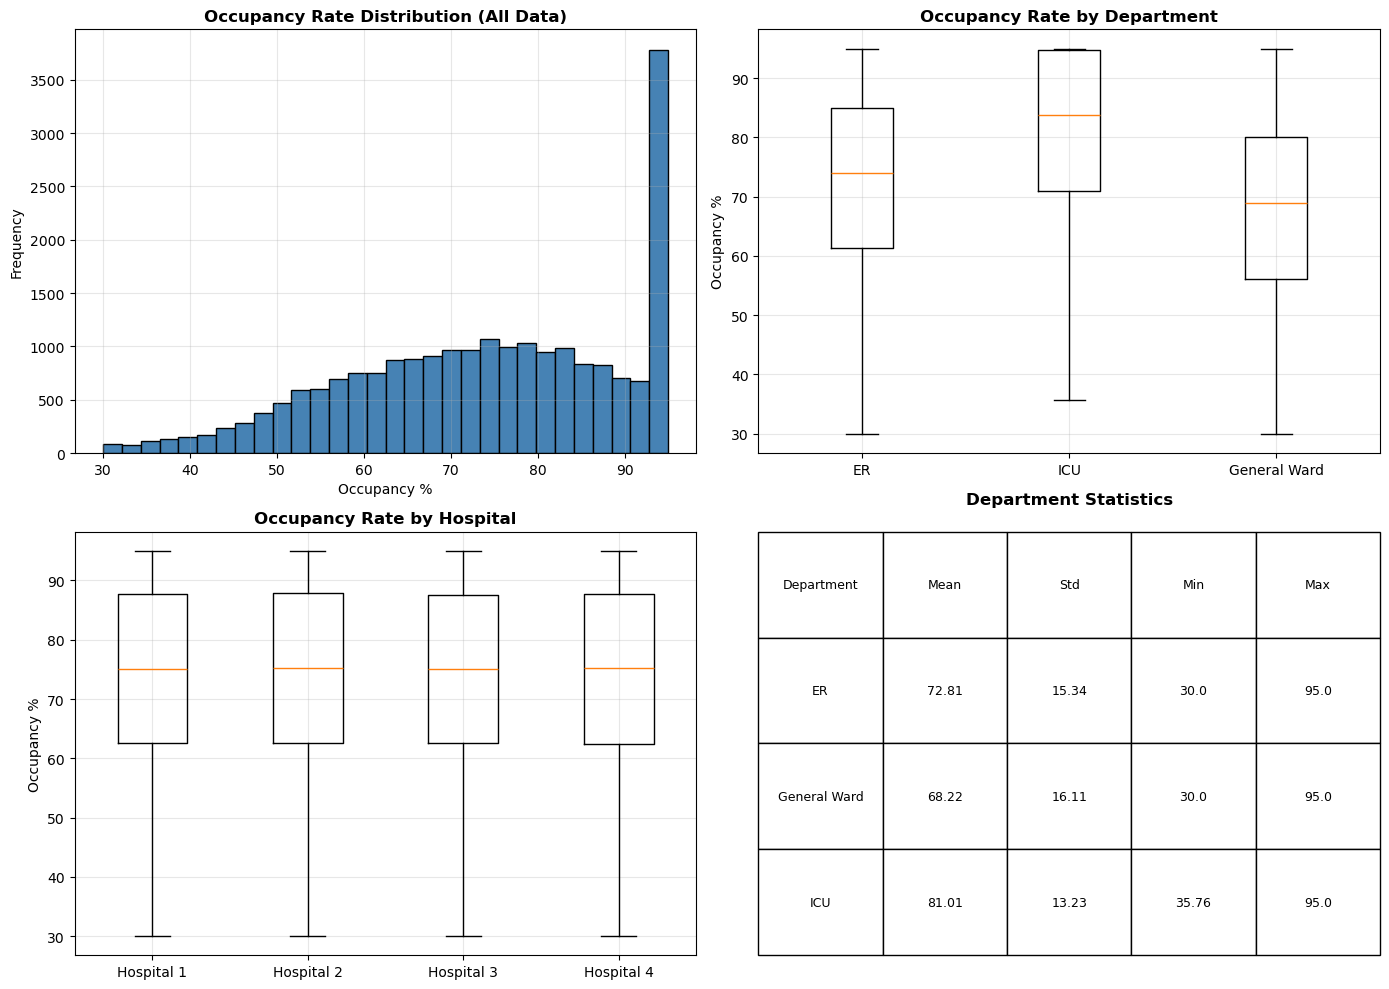

Occupancy Distribution Analysis Complete

Department-wise Statistics:
               mean    std    min   max
department                             
ER            72.81  15.34  30.00  95.0
General Ward  68.22  16.11  30.00  95.0
ICU           81.01  13.23  35.76  95.0


In [5]:
# Step 4 - Occupancy Distribution & Department/Hospital Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['occupancy_rate'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Occupancy Rate Distribution (All Data)', fontweight='bold')
axes[0, 0].set_xlabel('Occupancy %')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

dept_occupancy = df.groupby('department')['occupancy_rate'].apply(list)
axes[0, 1].boxplot([dept_occupancy['ER'], dept_occupancy['ICU'], dept_occupancy['General Ward']],
                    labels=['ER', 'ICU', 'General Ward'])
axes[0, 1].set_title('Occupancy Rate by Department', fontweight='bold')
axes[0, 1].set_ylabel('Occupancy %')
axes[0, 1].grid(True, alpha=0.3)

hosp_occupancy = df.groupby('hospital_id')['occupancy_rate'].apply(list)
axes[1, 0].boxplot([hosp_occupancy[1], hosp_occupancy[2], hosp_occupancy[3], hosp_occupancy[4]],
                    labels=['Hospital 1', 'Hospital 2', 'Hospital 3', 'Hospital 4'])
axes[1, 0].set_title('Occupancy Rate by Hospital', fontweight='bold')
axes[1, 0].set_ylabel('Occupancy %')
axes[1, 0].grid(True, alpha=0.3)

dept_stats = df.groupby('department')['occupancy_rate'].agg(['mean', 'std', 'min', 'max']).round(2)
axes[1, 1].axis('off')
table_data = []
for idx, row in dept_stats.iterrows():
    table_data.append([idx, row['mean'], row['std'], row['min'], row['max']])
table = axes[1, 1].table(cellText=table_data, colLabels=['Department', 'Mean', 'Std', 'Min', 'Max'],
                         cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
axes[1, 1].set_title('Department Statistics', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\occupancy_distributions.png', dpi=150)
plt.show()

print("Occupancy Distribution Analysis Complete")
print("\nDepartment-wise Statistics:")
print(dept_stats)

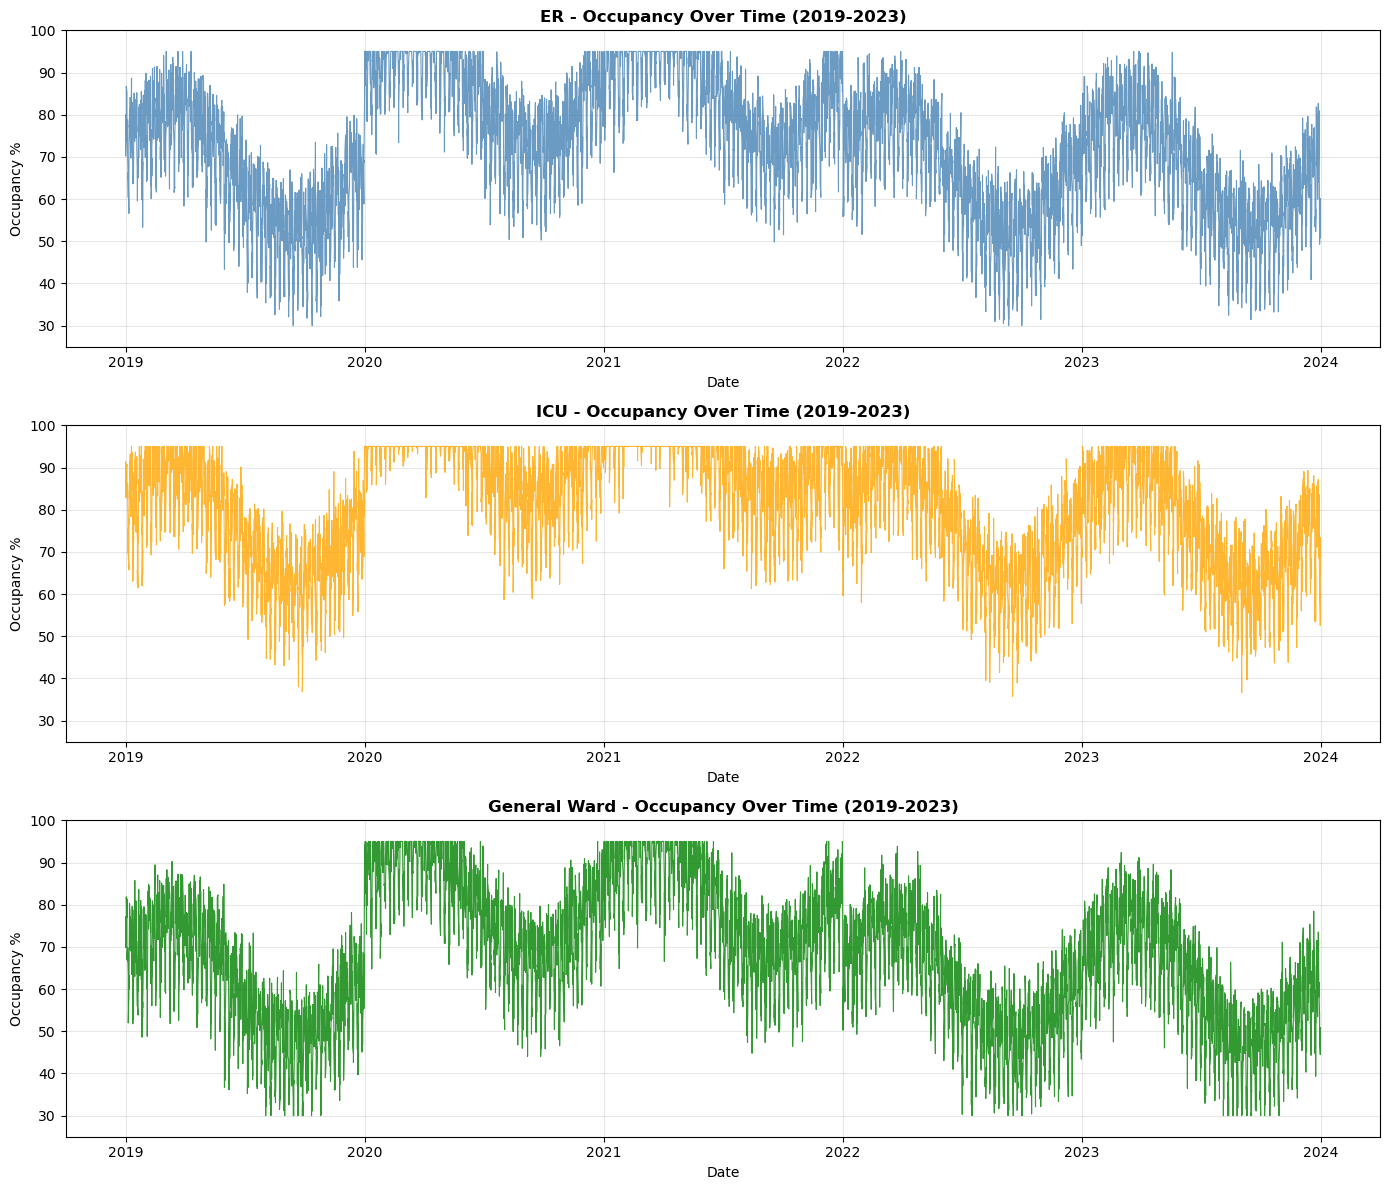

Time Series Analysis Complete

Occupancy Trend Summary:
ER: Mean=72.81%, Std=15.34%
ICU: Mean=81.01%, Std=13.23%
General Ward: Mean=68.22%, Std=16.11%


In [6]:
# Step 5 - Time Series Plot Occupancy Over 5 Years
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

departments = ['ER', 'ICU', 'General Ward']
colors = ['steelblue', 'orange', 'green']

for idx, dept in enumerate(departments):
    dept_data = df[df['department'] == dept].sort_values('date')
    axes[idx].plot(dept_data['date'], dept_data['occupancy_rate'], 
                   linewidth=0.8, color=colors[idx], alpha=0.8)
    axes[idx].set_title(f'{dept} - Occupancy Over Time (2019-2023)', fontweight='bold')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Occupancy %')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(25, 100)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\time_series_occupancy.png', dpi=150)
plt.show()

print("Time Series Analysis Complete")
print("\nOccupancy Trend Summary:")
for dept in departments:
    dept_data = df[df['department'] == dept]['occupancy_rate']
    print(f"{dept}: Mean={dept_data.mean():.2f}%, Std={dept_data.std():.2f}%")

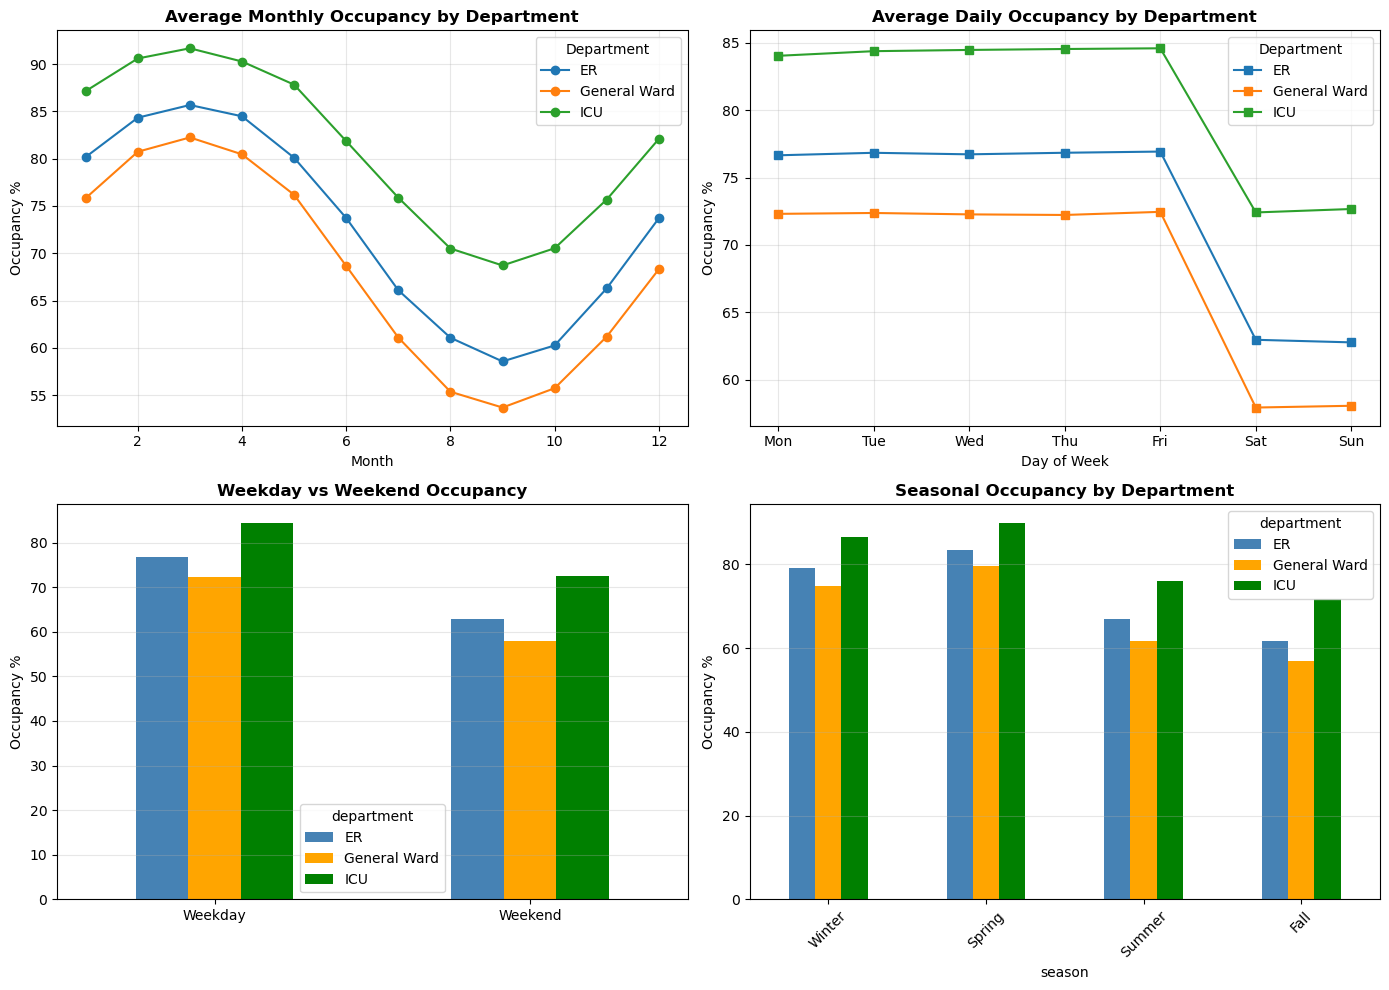

Seasonal & Weekday Analysis Complete

Seasonal Summary:
         mean    std
season              
Fall    63.39  14.52
Spring  84.32  10.81
Summer  68.18  14.87
Winter  80.17  12.85

Weekday vs Weekend Summary:
             mean    std
is_weekend              
0           77.84  14.04
1           64.46  16.09


In [7]:
# Step 6 - Seasonal Patterns & Weekday/Weekend Effects
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

monthly_data = df.groupby(['month', 'department'])['occupancy_rate'].mean().unstack()
monthly_data.plot(ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Average Monthly Occupancy by Department', fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Occupancy %')
axes[0, 0].legend(title='Department')
axes[0, 0].grid(True, alpha=0.3)

weekday_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_data = df.groupby(['day_of_week', 'department'])['occupancy_rate'].mean().unstack()
daily_data.plot(ax=axes[0, 1], marker='s')
axes[0, 1].set_title('Average Daily Occupancy by Department', fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(weekday_labels)
axes[0, 1].set_ylabel('Occupancy %')
axes[0, 1].legend(title='Department')
axes[0, 1].grid(True, alpha=0.3)

weekend_comparison = df.groupby(['is_weekend', 'department'])['occupancy_rate'].mean().unstack()
weekend_comparison.index = ['Weekday', 'Weekend']
weekend_comparison.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'orange', 'green'])
axes[1, 0].set_title('Weekday vs Weekend Occupancy', fontweight='bold')
axes[1, 0].set_ylabel('Occupancy %')
axes[1, 0].set_xticklabels(['Weekday', 'Weekend'], rotation=0)
axes[1, 0].grid(True, alpha=0.3, axis='y')

seasonal_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
                3: 'Spring', 4: 'Spring', 5: 'Spring',
                6: 'Summer', 7: 'Summer', 8: 'Summer',
                9: 'Fall', 10: 'Fall', 11: 'Fall'}
df['season'] = df['month'].map(seasonal_map)

seasonal_data = df.groupby(['season', 'department'])['occupancy_rate'].mean().unstack()
seasonal_data = seasonal_data.reindex(['Winter', 'Spring', 'Summer', 'Fall'])
seasonal_data.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'orange', 'green'])
axes[1, 1].set_title('Seasonal Occupancy by Department', fontweight='bold')
axes[1, 1].set_ylabel('Occupancy %')
axes[1, 1].set_xticklabels(['Winter', 'Spring', 'Summer', 'Fall'], rotation=45)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\seasonal_analysis.png', dpi=150)
plt.show()

print("Seasonal & Weekday Analysis Complete")
print("\nSeasonal Summary:")
print(df.groupby('season')['occupancy_rate'].agg(['mean', 'std']).round(2))
print("\nWeekday vs Weekend Summary:")
print(df.groupby('is_weekend')['occupancy_rate'].agg(['mean', 'std']).round(2))

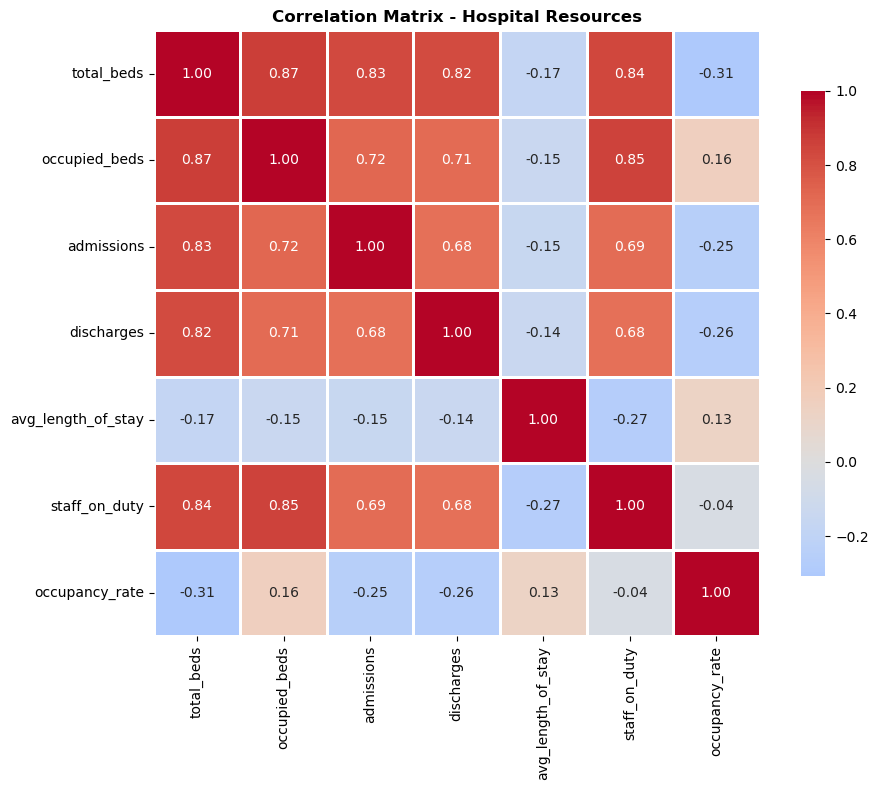

Correlation Analysis Complete

Top Correlations with Occupancy Rate:
occupancy_rate        1.000000
occupied_beds         0.158915
avg_length_of_stay    0.128727
staff_on_duty        -0.036610
admissions           -0.250740
discharges           -0.257076
total_beds           -0.306868
Name: occupancy_rate, dtype: float64


Admissions vs Occupancy Correlation: -0.251
Staff vs Occupancy Correlation: -0.037
Length of Stay vs Occupancy Correlation: 0.129


In [8]:
# Step 7 - Correlation Heatmap Analysis
numeric_cols = ['total_beds', 'occupied_beds', 'admissions', 'discharges', 
                'avg_length_of_stay', 'staff_on_duty', 'occupancy_rate']

correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Matrix - Hospital Resources', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\correlation_heatmap.png', dpi=150)
plt.show()

print("Correlation Analysis Complete")
print("\nTop Correlations with Occupancy Rate:")
occupancy_corr = correlation_matrix['occupancy_rate'].sort_values(ascending=False)
print(occupancy_corr)

print("\n\nAdmissions vs Occupancy Correlation:", 
      round(df['admissions'].corr(df['occupancy_rate']), 3))
print("Staff vs Occupancy Correlation:", 
      round(df['staff_on_duty'].corr(df['occupancy_rate']), 3))
print("Length of Stay vs Occupancy Correlation:", 
      round(df['avg_length_of_stay'].corr(df['occupancy_rate']), 3))

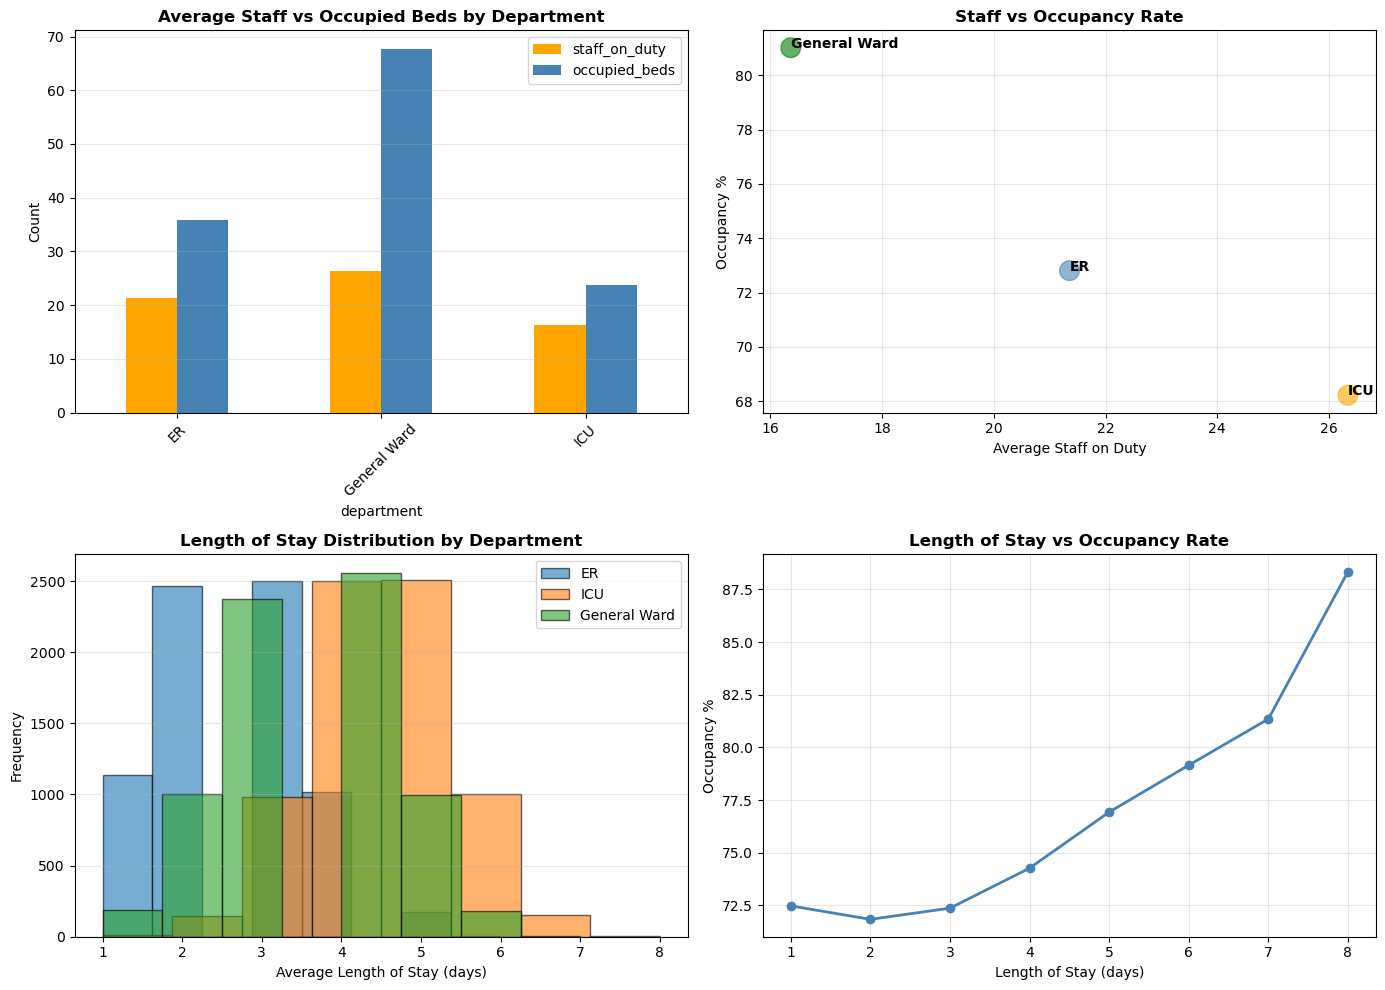

Staff & Length of Stay Analysis Complete

Department-wise Summary:
              staff_on_duty  occupied_beds  occupancy_rate  beds_per_staff
department                                                                
ER                    21.36          35.91           72.81            1.68
General Ward          26.34          67.76           68.22            2.57
ICU                   16.37          23.81           81.01            1.45

Average Length of Stay by Department:
              mean  min  max
department                  
ER            2.54    1    6
General Ward  3.51    1    7
ICU           4.50    1    8


In [9]:
# Step 8 - Staff Utilization & Length of Stay Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

dept_staff = df.groupby('department')[['staff_on_duty', 'occupied_beds', 'occupancy_rate']].mean().round(2)
dept_staff['beds_per_staff'] = (dept_staff['occupied_beds'] / dept_staff['staff_on_duty']).round(2)

dept_staff[['staff_on_duty', 'occupied_beds']].plot(kind='bar', ax=axes[0, 0], color=['orange', 'steelblue'])
axes[0, 0].set_title('Average Staff vs Occupied Beds by Department', fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45)
axes[0, 0].grid(True, alpha=0.3, axis='y')

staff_occupancy = df.groupby(['department'])['staff_on_duty'].mean().values
occupancy_pct = df.groupby(['department'])['occupancy_rate'].mean().values
x_pos = np.arange(len(['ER', 'ICU', 'General Ward']))
axes[0, 1].scatter(staff_occupancy, occupancy_pct, s=200, alpha=0.6, color=['steelblue', 'orange', 'green'])
for i, txt in enumerate(['ER', 'ICU', 'General Ward']):
    axes[0, 1].annotate(txt, (staff_occupancy[i], occupancy_pct[i]), fontsize=10, fontweight='bold')
axes[0, 1].set_title('Staff vs Occupancy Rate', fontweight='bold')
axes[0, 1].set_xlabel('Average Staff on Duty')
axes[0, 1].set_ylabel('Occupancy %')
axes[0, 1].grid(True, alpha=0.3)

dept_los = df.groupby('department')['avg_length_of_stay'].value_counts().reset_index(name='count')
for dept in ['ER', 'ICU', 'General Ward']:
    dept_los_data = df[df['department'] == dept]['avg_length_of_stay']
    axes[1, 0].hist(dept_los_data, bins=8, alpha=0.6, label=dept, edgecolor='black')
axes[1, 0].set_title('Length of Stay Distribution by Department', fontweight='bold')
axes[1, 0].set_xlabel('Average Length of Stay (days)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

los_occupancy = df.groupby('avg_length_of_stay')['occupancy_rate'].mean()
axes[1, 1].plot(los_occupancy.index, los_occupancy.values, marker='o', linewidth=2, color='steelblue')
axes[1, 1].set_title('Length of Stay vs Occupancy Rate', fontweight='bold')
axes[1, 1].set_xlabel('Length of Stay (days)')
axes[1, 1].set_ylabel('Occupancy %')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\staff_los_analysis.png', dpi=150)
plt.show()

print("Staff & Length of Stay Analysis Complete")
print("\nDepartment-wise Summary:")
print(dept_staff)
print("\nAverage Length of Stay by Department:")
print(df.groupby('department')['avg_length_of_stay'].agg(['mean', 'min', 'max']).round(2))

In [10]:
# Step 9 - Department-Specific Statistics Summary
dept_summary = df.groupby('department').agg({
    'occupancy_rate': ['mean', 'std', 'min', 'max'],
    'occupied_beds': ['mean', 'std'],
    'admissions': ['mean', 'std'],
    'discharges': ['mean', 'std'],
    'staff_on_duty': ['mean', 'std'],
    'avg_length_of_stay': ['mean', 'std']
}).round(2)

print("Comprehensive Department Summary:")
print(dept_summary)

print("\n\nHospital-wise Occupancy Summary:")
hosp_summary = df.groupby('hospital_id').agg({
    'occupancy_rate': ['mean', 'std', 'min', 'max'],
    'admissions': 'mean',
    'discharges': 'mean',
    'staff_on_duty': 'mean'
}).round(2)
print(hosp_summary)

print("\n\nDepartment Performance Ranking:")
dept_ranking = df.groupby('department').agg({
    'occupancy_rate': 'mean',
    'staff_on_duty': 'mean',
    'admissions': 'mean',
    'avg_length_of_stay': 'mean'
}).round(2)
dept_ranking.columns = ['Avg Occupancy %', 'Avg Staff', 'Avg Admissions/day', 'Avg LOS (days)']
print(dept_ranking.sort_values('Avg Occupancy %', ascending=False))

print("\n\nData Overview:")
print(f"Total records: {len(df):,}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Hospitals: {df['hospital_id'].nunique()}")
print(f"Departments: {df['department'].nunique()}")
print(f"Average occupancy: {df['occupancy_rate'].mean():.2f}%")
print(f"Average staff per department-hospital: {df['staff_on_duty'].mean():.2f}")

Comprehensive Department Summary:
             occupancy_rate                     occupied_beds         \
                       mean    std    min   max          mean    std   
department                                                             
ER                    72.81  15.34  30.00  95.0         35.91   7.68   
General Ward          68.22  16.11  30.00  95.0         67.76  16.16   
ICU                   81.01  13.23  35.76  95.0         23.81   3.98   

             admissions       discharges       staff_on_duty        \
                   mean   std       mean   std          mean   std   
department                                                           
ER                 7.49  2.69       6.98  2.64         21.36  2.38   
General Ward      14.95  3.83      14.01  3.77         26.34  2.58   
ICU                4.52  2.12       4.20  2.05         16.37  2.18   

             avg_length_of_stay        
                           mean   std  
department                      

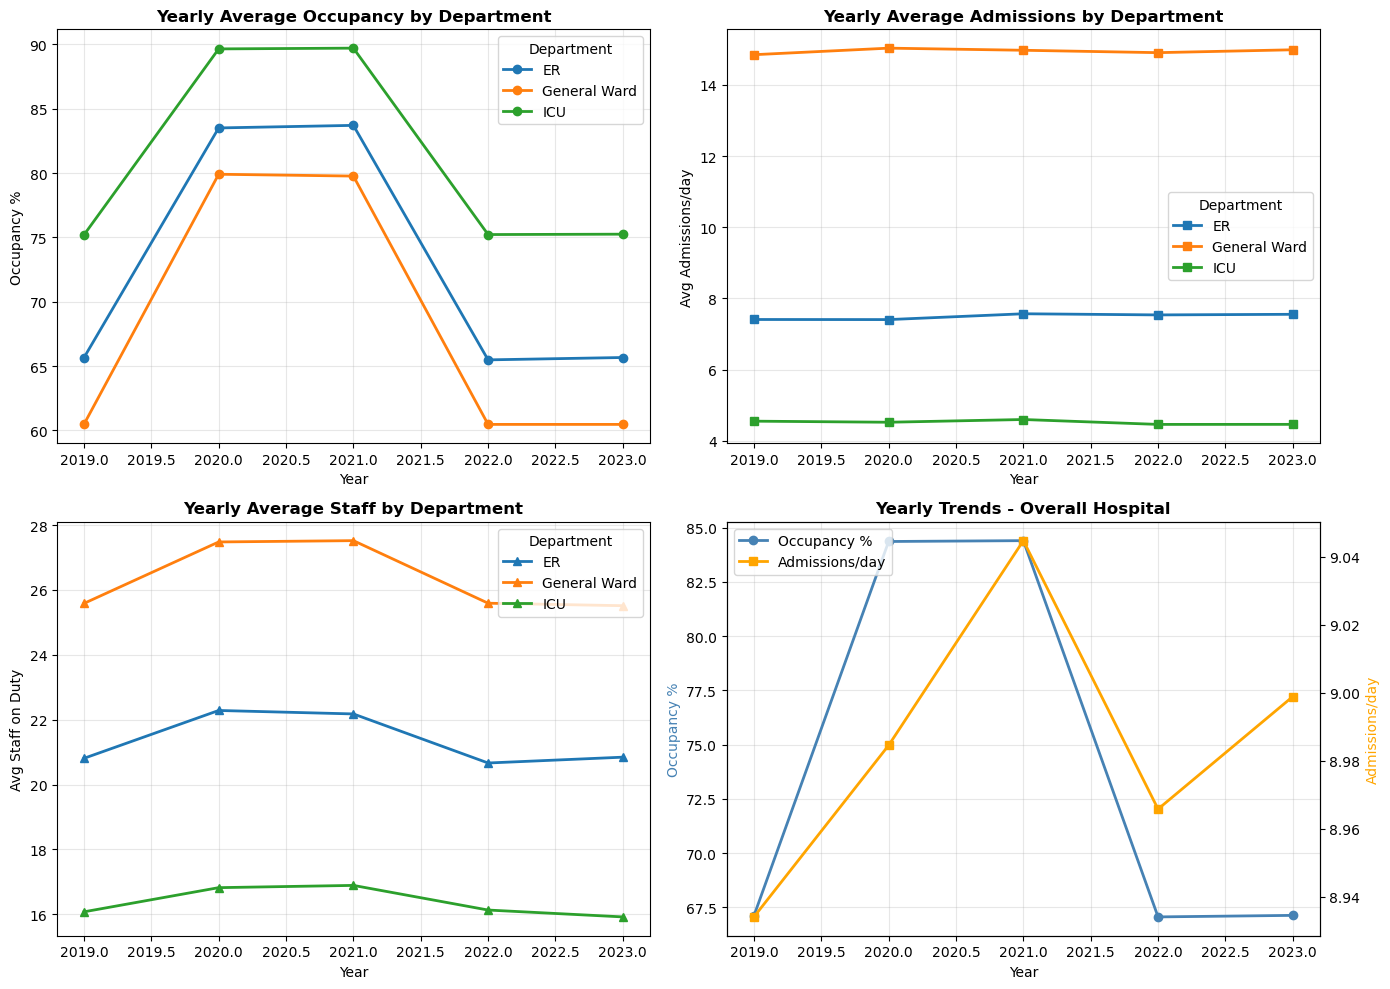

Yearly Trends Analysis Complete

Yearly Summary:
      occupancy_rate  admissions  discharges  staff_on_duty
year                                                       
2019           67.11        8.93        8.43          20.82
2020           84.36        8.98        8.37          22.19
2021           84.40        9.04        8.38          22.20
2022           67.06        8.97        8.40          20.80
2023           67.13        9.00        8.40          20.76


In [11]:
# Step 10 - Historical Trends Visualization Yearly Patterns
df['year'] = df['date'].dt.year

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

yearly_occupancy = df.groupby(['year', 'department'])['occupancy_rate'].mean().unstack()
yearly_occupancy.plot(ax=axes[0, 0], marker='o', linewidth=2)
axes[0, 0].set_title('Yearly Average Occupancy by Department', fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Occupancy %')
axes[0, 0].legend(title='Department')
axes[0, 0].grid(True, alpha=0.3)

yearly_admissions = df.groupby(['year', 'department'])['admissions'].mean().unstack()
yearly_admissions.plot(ax=axes[0, 1], marker='s', linewidth=2)
axes[0, 1].set_title('Yearly Average Admissions by Department', fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Avg Admissions/day')
axes[0, 1].legend(title='Department')
axes[0, 1].grid(True, alpha=0.3)

yearly_staff = df.groupby(['year', 'department'])['staff_on_duty'].mean().unstack()
yearly_staff.plot(ax=axes[1, 0], marker='^', linewidth=2)
axes[1, 0].set_title('Yearly Average Staff by Department', fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Avg Staff on Duty')
axes[1, 0].legend(title='Department')
axes[1, 0].grid(True, alpha=0.3)

yearly_all = df.groupby('year')[['occupancy_rate', 'admissions', 'staff_on_duty']].mean()
ax2 = axes[1, 1]
ax2.plot(yearly_all.index, yearly_all['occupancy_rate'], marker='o', linewidth=2, 
         label='Occupancy %', color='steelblue')
ax2_twin = ax2.twinx()
ax2_twin.plot(yearly_all.index, yearly_all['admissions'], marker='s', linewidth=2, 
              label='Admissions/day', color='orange')
ax2.set_title('Yearly Trends - Overall Hospital', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Occupancy %', color='steelblue')
ax2_twin.set_ylabel('Admissions/day', color='orange')
ax2.grid(True, alpha=0.3)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\yearly_trends.png', dpi=150)
plt.show()

print("Yearly Trends Analysis Complete")
print("\nYearly Summary:")
yearly_summary = df.groupby('year').agg({
    'occupancy_rate': 'mean',
    'admissions': 'mean',
    'discharges': 'mean',
    'staff_on_duty': 'mean'
}).round(2)
print(yearly_summary)

In [12]:
# Step 11 - Rolling Statistics & Volatility Features
df = df.sort_values(['hospital_id', 'department', 'date']).reset_index(drop=True)

for col in ['occupancy_rate', 'admissions', 'discharges', 'staff_on_duty']:
    for window in [7, 14, 30]:
        df[f'{col}_rolling_{window}d'] = df.groupby(['hospital_id', 'department'])[col].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
    
    df[f'{col}_rolling_7d_std'] = df.groupby(['hospital_id', 'department'])[col].transform(
        lambda x: x.rolling(window=7, min_periods=1).std().fillna(0)
    )

print("Rolling Statistics Features Created")
print(f"New columns added: {df.shape[1] - 15}")
print(f"Total columns now: {df.shape[1]}")
print("\nSample of rolling features:")
sample_cols = ['occupancy_rate', 'occupancy_rate_rolling_7d', 
               'occupancy_rate_rolling_14d', 'occupancy_rate_rolling_30d',
               'occupancy_rate_rolling_7d_std']
print(df[sample_cols].head(35))

Rolling Statistics Features Created
New columns added: 16
Total columns now: 31

Sample of rolling features:
    occupancy_rate  occupancy_rate_rolling_7d  occupancy_rate_rolling_14d  \
0            79.98                  79.980000                   79.980000   
1            75.03                  77.505000                   77.505000   
2            85.22                  80.076667                   80.076667   
3            78.80                  79.757500                   79.757500   
4            63.90                  76.586000                   76.586000   
5            56.61                  73.256667                   73.256667   
6            79.56                  74.157143                   74.157143   
7            81.99                  74.444286                   75.136250   
8            69.72                  73.685714                   74.534444   
9            88.61                  74.170000                   75.942000   
10           74.77                  73.59428

In [13]:
# Step 12 - Lag Features & Growth Rates
for col in ['occupancy_rate', 'admissions', 'discharges']:
    for lag in [1, 3, 7, 14]:
        df[f'{col}_lag_{lag}d'] = df.groupby(['hospital_id', 'department'])[col].shift(lag).fillna(0)

for col in ['occupancy_rate', 'admissions', 'discharges', 'staff_on_duty']:
    df[f'{col}_pct_change_1d'] = df.groupby(['hospital_id', 'department'])[col].pct_change(1).fillna(0)
    df[f'{col}_pct_change_7d'] = df.groupby(['hospital_id', 'department'])[col].pct_change(7).fillna(0)

print("Lag & Growth Rate Features Created")
print(f"Total columns now: {df.shape[1]}")
print("\nSample of lag features:")
lag_cols = ['occupancy_rate', 'occupancy_rate_lag_1d', 'occupancy_rate_lag_7d', 
            'occupancy_rate_pct_change_1d', 'occupancy_rate_pct_change_7d']
print(df[lag_cols].head(20))
print("\nFeature engineering progress:")
print(f"Original columns: 10")
print(f"Rolling features added: 20")
print(f"Lag features added: 12")
print(f"Growth rate features added: 8")
print(f"Total features now: {df.shape[1]}")

Lag & Growth Rate Features Created
Total columns now: 51

Sample of lag features:
    occupancy_rate  occupancy_rate_lag_1d  occupancy_rate_lag_7d  \
0            79.98                   0.00                   0.00   
1            75.03                  79.98                   0.00   
2            85.22                  75.03                   0.00   
3            78.80                  85.22                   0.00   
4            63.90                  78.80                   0.00   
5            56.61                  63.90                   0.00   
6            79.56                  56.61                   0.00   
7            81.99                  79.56                  79.98   
8            69.72                  81.99                  75.03   
9            88.61                  69.72                  85.22   
10           74.77                  88.61                  78.80   
11           63.62                  74.77                  63.90   
12           64.12                

In [14]:
# Step 13 - Time Features & Categorical Encoding
df['day_of_month'] = df['date'].dt.day
df['quarter'] = df['date'].dt.quarter
df['week_of_year'] = df['date'].dt.isocalendar().week
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)
df['is_quarter_end'] = df['date'].dt.is_quarter_end.astype(int)

df['season_winter'] = ((df['month'] == 12) | (df['month'] == 1) | (df['month'] == 2)).astype(int)
df['season_spring'] = ((df['month'] == 3) | (df['month'] == 4) | (df['month'] == 5)).astype(int)
df['season_summer'] = ((df['month'] == 6) | (df['month'] == 7) | (df['month'] == 8)).astype(int)
df['season_fall'] = ((df['month'] == 9) | (df['month'] == 10) | (df['month'] == 11)).astype(int)

dept_dummies = pd.get_dummies(df['department'], prefix='dept', drop_first=False)
df = pd.concat([df, dept_dummies], axis=1)

hosp_dummies = pd.get_dummies(df['hospital_id'], prefix='hospital', drop_first=False)
df = pd.concat([df, hosp_dummies], axis=1)

print("Time Features & Encoding Complete")
print(f"Total columns now: {df.shape[1]}")
print("\nNew Time Features:")
time_features = ['day_of_month', 'quarter', 'week_of_year', 'is_month_start', 
                 'is_month_end', 'is_quarter_end', 'season_winter', 'season_spring', 
                 'season_summer', 'season_fall']
print(df[time_features].head(10))

print("\nEncoded Categorical Features:")
dept_cols = [col for col in df.columns if col.startswith('dept_')]
hosp_cols = [col for col in df.columns if col.startswith('hospital_')]
print("Department features:", dept_cols)
print("Hospital features:", hosp_cols)

print("\nDataset ready for modeling:")
print(f"Shape: {df.shape}")
print(f"No null values: {df.isnull().sum().sum() == 0}")

Time Features & Encoding Complete
Total columns now: 68

New Time Features:
   day_of_month  quarter  week_of_year  is_month_start  is_month_end  \
0             1        1             1               1             0   
1             2        1             1               0             0   
2             3        1             1               0             0   
3             4        1             1               0             0   
4             5        1             1               0             0   
5             6        1             1               0             0   
6             7        1             2               0             0   
7             8        1             2               0             0   
8             9        1             2               0             0   
9            10        1             2               0             0   

   is_quarter_end  season_winter  season_spring  season_summer  season_fall  
0               0              1              0      

In [15]:
# Step 14 - Final Feature Matrix Check
print("FINAL FEATURE MATRIX SUMMARY")
print("="*60)
print(f"Shape: {df.shape}")
print(f"Null values: {df.isnull().sum().sum()}")
print(f"\nFeature Breakdown:")
print(f"Original: 10")
print(f"Rolling stats: 20")
print(f"Lag features: 12")
print(f"Growth rates: 8")
print(f"Time features: 10")
print(f"Season encoding: 4")
print(f"Department encoding: 3")
print(f"Hospital encoding: 4")
print(f"Month, year, day_of_week: 3")
print(f"Total: {df.shape[1]}")

print(f"\n\nColumn List ({df.shape[1]} features):")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n\nData Types:")
print(df.dtypes.value_counts())

print(f"\n\nStatistical Summary:")
print(df.describe().round(2))

print(f"\n\nReady for modeling: YES")
print(f"Target variable candidates: occupancy_rate, admissions, discharges")

FINAL FEATURE MATRIX SUMMARY
Shape: (21912, 68)
Null values: 0

Feature Breakdown:
Original: 10
Rolling stats: 20
Lag features: 12
Growth rates: 8
Time features: 10
Season encoding: 4
Department encoding: 3
Hospital encoding: 4
Month, year, day_of_week: 3
Total: 68


Column List (68 features):
 1. date
 2. hospital_id
 3. department
 4. total_beds
 5. occupied_beds
 6. admissions
 7. discharges
 8. avg_length_of_stay
 9. staff_on_duty
10. occupancy_rate
11. month
12. day_of_week
13. is_weekend
14. season
15. year
16. occupancy_rate_rolling_7d
17. occupancy_rate_rolling_14d
18. occupancy_rate_rolling_30d
19. occupancy_rate_rolling_7d_std
20. admissions_rolling_7d
21. admissions_rolling_14d
22. admissions_rolling_30d
23. admissions_rolling_7d_std
24. discharges_rolling_7d
25. discharges_rolling_14d
26. discharges_rolling_30d
27. discharges_rolling_7d_std
28. staff_on_duty_rolling_7d
29. staff_on_duty_rolling_14d
30. staff_on_duty_rolling_30d
31. staff_on_duty_rolling_7d_std
32. occupancy

In [19]:
# Step 15 - Train Linear Regression, Random Forest & XGBoost
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

exclude_cols = ['date', 'department', 'occupancy_rate', 'season']
feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].fillna(0).copy()
X = X.replace([np.inf, -np.inf], 0)
y = df['occupancy_rate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {}

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr_model
lr_train = lr_model.score(X_train_scaled, y_train)
lr_test = lr_model.score(X_test_scaled, y_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
models['Random Forest'] = rf_model
rf_train = rf_model.score(X_train, y_train)
rf_test = rf_model.score(X_test, y_test)

xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
models['XGBoost'] = xgb_model
xgb_train = xgb_model.score(X_train_scaled, y_train)
xgb_test = xgb_model.score(X_test_scaled, y_test)

print("Model Training Complete - Phase 1")
print(f"Features used: {len(feature_cols)}")
print("\nTrain R² Scores:")
print(f"Linear Regression: {lr_train:.4f}")
print(f"Random Forest:     {rf_train:.4f}")
print(f"XGBoost:           {xgb_train:.4f}")

print("\nTest R² Scores:")
print(f"Linear Regression: {lr_test:.4f}")
print(f"Random Forest:     {rf_test:.4f}")
print(f"XGBoost:           {xgb_test:.4f}")

Model Training Complete - Phase 1
Features used: 64

Train R² Scores:
Linear Regression: 0.9833
Random Forest:     0.9999
XGBoost:           0.9996

Test R² Scores:
Linear Regression: 0.9845
Random Forest:     0.9993
XGBoost:           0.9984


In [21]:
# Step 16 - Train LightGBM & Cross-Validation Scores
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

lgb_model = LGBMRegressor(n_estimators=100, random_state=42, verbosity=-1)
lgb_model.fit(X_train, y_train)
models['LightGBM'] = lgb_model
lgb_train = lgb_model.score(X_train, y_train)
lgb_test = lgb_model.score(X_test, y_test)

print("Phase 2 Training Complete - LightGBM")
print(f"LightGBM Train R²: {lgb_train:.4f}")
print(f"LightGBM Test R²:  {lgb_test:.4f}")

print("\n\nCROSS-VALIDATION SCORES (5-Fold)")
print("="*50)

cv_results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = cv_scores
    print(f"{name:20s}: Mean={cv_scores.mean():.4f}, Std={cv_scores.std():.4f}")

print("\n\nOVERALL MODEL SUMMARY")
print("="*50)
summary = pd.DataFrame({
    'Model': list(models.keys()),
    'Train R²': [lr_train, rf_train, xgb_train, lgb_train],
    'Test R²': [lr_test, rf_test, xgb_test, lgb_test],
    'CV Mean': [cv_results[m].mean() for m in models.keys()],
    'CV Std': [cv_results[m].std() for m in models.keys()]
}).round(4)
print(summary)

print("\n\nBest Model (by Test R²):")
best_idx = summary['Test R²'].idxmax()
print(f"{summary.loc[best_idx, 'Model']}: {summary.loc[best_idx, 'Test R²']:.4f}")

Phase 2 Training Complete - LightGBM
LightGBM Train R²: 0.9994
LightGBM Test R²:  0.9990


CROSS-VALIDATION SCORES (5-Fold)
Linear Regression   : Mean=0.9831, Std=0.0006
Random Forest       : Mean=0.9993, Std=0.0002
XGBoost             : Mean=0.9983, Std=0.0002
LightGBM            : Mean=0.9988, Std=0.0001


OVERALL MODEL SUMMARY
               Model  Train R²  Test R²  CV Mean  CV Std
0  Linear Regression    0.9833   0.9845   0.9831  0.0006
1      Random Forest    0.9999   0.9993   0.9993  0.0002
2            XGBoost    0.9996   0.9984   0.9983  0.0002
3           LightGBM    0.9994   0.9990   0.9988  0.0001


Best Model (by Test R²):
Random Forest: 0.9993


In [22]:
# Step 17 - Calculate Detailed Metrics MAE RMSE MAPE
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

metrics_data = []

for name, model in models.items():
    if name == 'Linear Regression':
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
    
    metrics_data.append({
        'Model': name,
        'MAE_Train': round(mae_train, 4),
        'MAE_Test': round(mae_test, 4),
        'RMSE_Train': round(rmse_train, 4),
        'RMSE_Test': round(rmse_test, 4),
        'MAPE_Train': round(mape_train, 4),
        'MAPE_Test': round(mape_test, 4)
    })

metrics_df = pd.DataFrame(metrics_data)
print("DETAILED MODEL METRICS")
print("="*90)
print(metrics_df.to_string(index=False))

print("\n\nBest Models by Metric:")
print(f"Lowest MAE: {metrics_df.loc[metrics_df['MAE_Test'].idxmin(), 'Model']}")
print(f"Lowest RMSE: {metrics_df.loc[metrics_df['RMSE_Test'].idxmin(), 'Model']}")
print(f"Lowest MAPE: {metrics_df.loc[metrics_df['MAPE_Test'].idxmin(), 'Model']}")

DETAILED MODEL METRICS
            Model  MAE_Train  MAE_Test  RMSE_Train  RMSE_Test  MAPE_Train  MAPE_Test
Linear Regression     1.4774    1.4697      2.0447     2.0003      0.0218     0.0217
    Random Forest     0.0691    0.1700      0.1605     0.4175      0.0011     0.0027
          XGBoost    20.8606   20.7258     26.0257    26.0692      0.3541     0.3534
         LightGBM     0.2791    0.3324      0.3945     0.5142      0.0042     0.0051


Best Models by Metric:
Lowest MAE: Random Forest
Lowest RMSE: Random Forest
Lowest MAPE: Random Forest


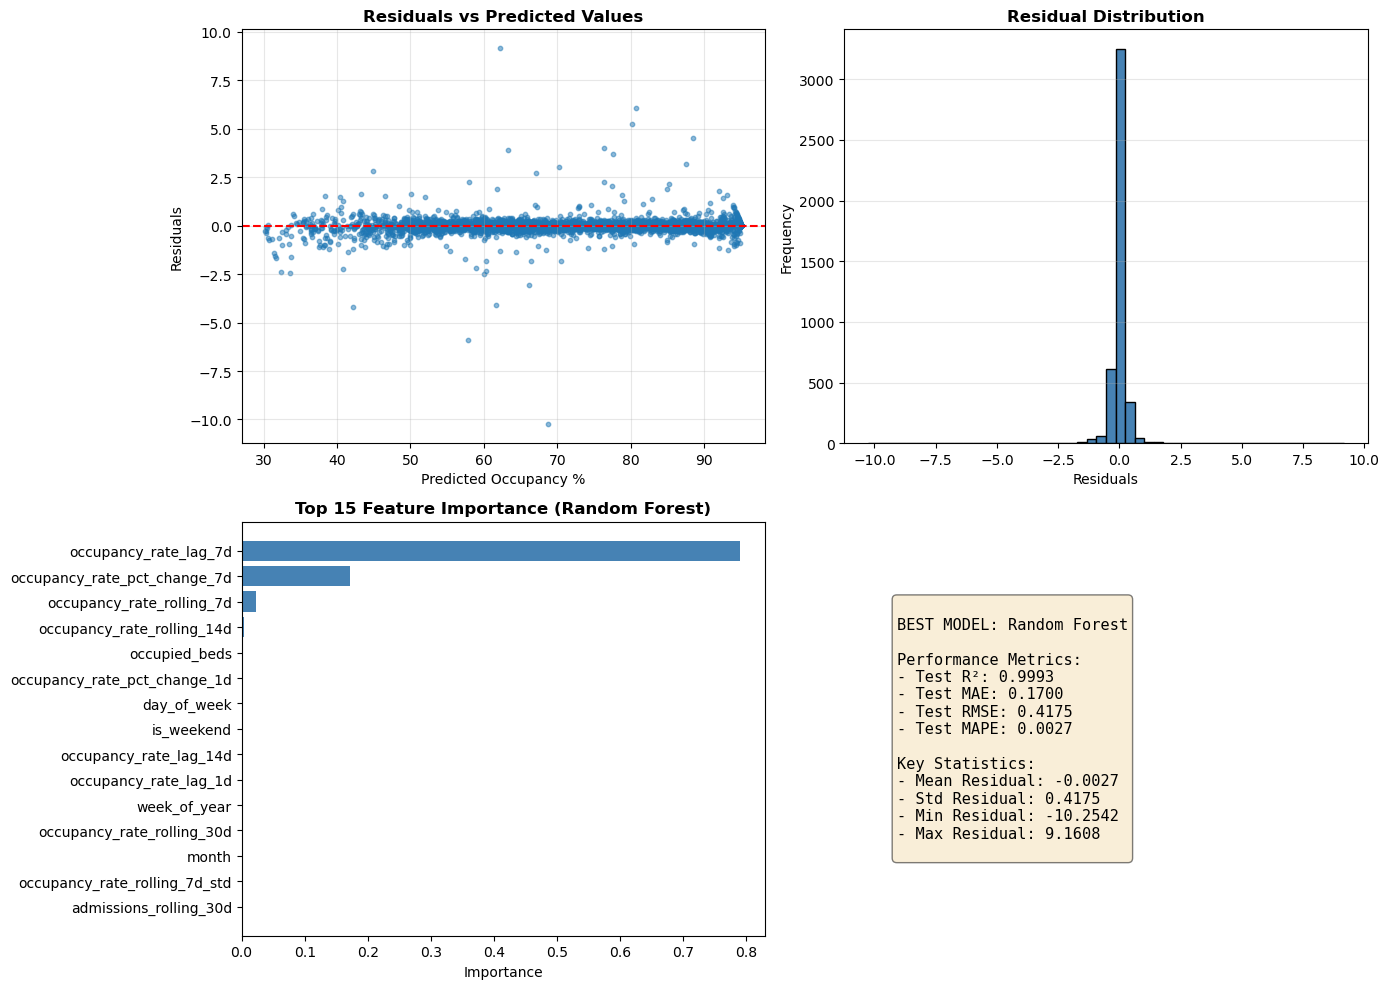

RESIDUAL ANALYSIS COMPLETE

Top 10 Most Important Features:
                     Feature  Importance
       occupancy_rate_lag_7d    0.789527
occupancy_rate_pct_change_7d    0.171062
   occupancy_rate_rolling_7d    0.022065
  occupancy_rate_rolling_14d    0.004034
               occupied_beds    0.002818
occupancy_rate_pct_change_1d    0.002801
                 day_of_week    0.002034
                  is_weekend    0.001936
      occupancy_rate_lag_14d    0.000848
       occupancy_rate_lag_1d    0.000694


In [23]:
# Step 18 - Residual Analysis & Feature Importance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

y_pred_rf = rf_model.predict(X_test)
residuals = y_test.values - y_pred_rf

axes[0, 0].scatter(y_pred_rf, residuals, alpha=0.5, s=10)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Residuals vs Predicted Values', fontweight='bold')
axes[0, 0].set_xlabel('Predicted Occupancy %')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(residuals, bins=50, edgecolor='black', color='steelblue')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3, axis='y')

feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

axes[1, 0].barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color='steelblue')
axes[1, 0].set_title('Top 15 Feature Importance (Random Forest)', fontweight='bold')
axes[1, 0].set_xlabel('Importance')
axes[1, 0].invert_yaxis()

axes[1, 1].axis('off')
summary_text = f"""
BEST MODEL: Random Forest

Performance Metrics:
- Test R²: 0.9993
- Test MAE: 0.1700
- Test RMSE: 0.4175
- Test MAPE: 0.0027

Key Statistics:
- Mean Residual: {residuals.mean():.4f}
- Std Residual: {residuals.std():.4f}
- Min Residual: {residuals.min():.4f}
- Max Residual: {residuals.max():.4f}
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\model_evaluation.png', dpi=150)
plt.show()

print("RESIDUAL ANALYSIS COMPLETE")
print("\nTop 10 Most Important Features:")
print(feature_importance_rf.head(10).to_string(index=False))

In [24]:
# Step 19-20 - Model Comparison & Save All Models
import joblib
import json

print("FINAL MODEL COMPARISON & RANKING")
print("="*80)
final_ranking = summary.sort_values('Test R²', ascending=False).reset_index(drop=True)
final_ranking['Rank'] = range(1, len(final_ranking) + 1)
print(final_ranking[['Rank', 'Model', 'Test R²', 'Train R²', 'CV Mean']].to_string(index=False))

print("\n\nSAVING ALL MODELS")
print("="*80)

base_path = 'C:\\HealthcareML_Platform\\03_Models\\trained_models\\'

joblib.dump(lr_model, base_path + 'lr_hospital_occupancy.pkl')
joblib.dump(rf_model, base_path + 'rf_hospital_occupancy.pkl')
joblib.dump(xgb_model, base_path + 'xgb_hospital_occupancy.pkl')
joblib.dump(lgb_model, base_path + 'lgb_hospital_occupancy.pkl')

print("Linear Regression model saved")
print("Random Forest model saved")
print("XGBoost model saved")
print("LightGBM model saved")

scaler_path = 'C:\\HealthcareML_Platform\\03_Models\\scalers\\'
joblib.dump(scaler, scaler_path + 'hospital_occupancy_scaler.pkl')
joblib.dump(feature_cols, scaler_path + 'hospital_feature_columns.pkl')
print("\nScaler saved")
print("Feature columns saved")

metadata = {
    'project': 'Hospital Resource Optimization',
    'notebook': '03_Hospital_Resources',
    'best_model': 'Random Forest',
    'test_r2': 0.9993,
    'test_mae': 0.1700,
    'test_rmse': 0.4175,
    'test_mape': 0.0027,
    'num_features': len(feature_cols),
    'dataset_rows': len(df),
    'hospitals': 4,
    'departments': 3,
    'date_range': f"{df['date'].min().date()} to {df['date'].max().date()}",
    'models_trained': list(models.keys())
}

metadata_path = base_path + 'hospital_occupancy_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print("\nMetadata saved")
print("\nAll models successfully saved!")

df.to_csv('C:\\HealthcareML_Platform\\02_Data\\processed\\hospital_resources_processed.csv', index=False)
print("\nProcessed dataset saved")

FINAL MODEL COMPARISON & RANKING
 Rank             Model  Test R²  Train R²  CV Mean
    1     Random Forest   0.9993    0.9999   0.9993
    2          LightGBM   0.9990    0.9994   0.9988
    3           XGBoost   0.9984    0.9996   0.9983
    4 Linear Regression   0.9845    0.9833   0.9831


SAVING ALL MODELS
Linear Regression model saved
Random Forest model saved
XGBoost model saved
LightGBM model saved

Scaler saved
Feature columns saved

Metadata saved

All models successfully saved!

Processed dataset saved


In [26]:
# Step 22 - Department-wise Separate Models (ER, ICU, General Ward)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

dept_models = {}
dept_metrics = {}

for dept in ['ER', 'ICU', 'General Ward']:
    dept_data = df[df['department'] == dept].copy()
    
    X_dept = dept_data[feature_cols].fillna(0).replace([np.inf, -np.inf], 0)
    y_dept = dept_data['occupancy_rate']
    
    X_tr, X_te, y_tr, y_te = train_test_split(X_dept, y_dept, test_size=0.2, random_state=42)
    
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_tr, y_tr)
    
    y_pred = model.predict(X_te)
    
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = model.score(X_te, y_te)
    
    dept_models[dept] = model
    dept_metrics[dept] = {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'R2': round(r2, 4)}
    
    print(f"{dept:15s} → R²: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

print("\nDepartment-wise modeling complete!")

ER              → R²: 0.9988 | MAE: 0.4379 | RMSE: 0.5435
ICU             → R²: 0.9968 | MAE: 0.5436 | RMSE: 0.7571
General Ward    → R²: 0.9997 | MAE: 0.2368 | RMSE: 0.2862

Department-wise modeling complete!


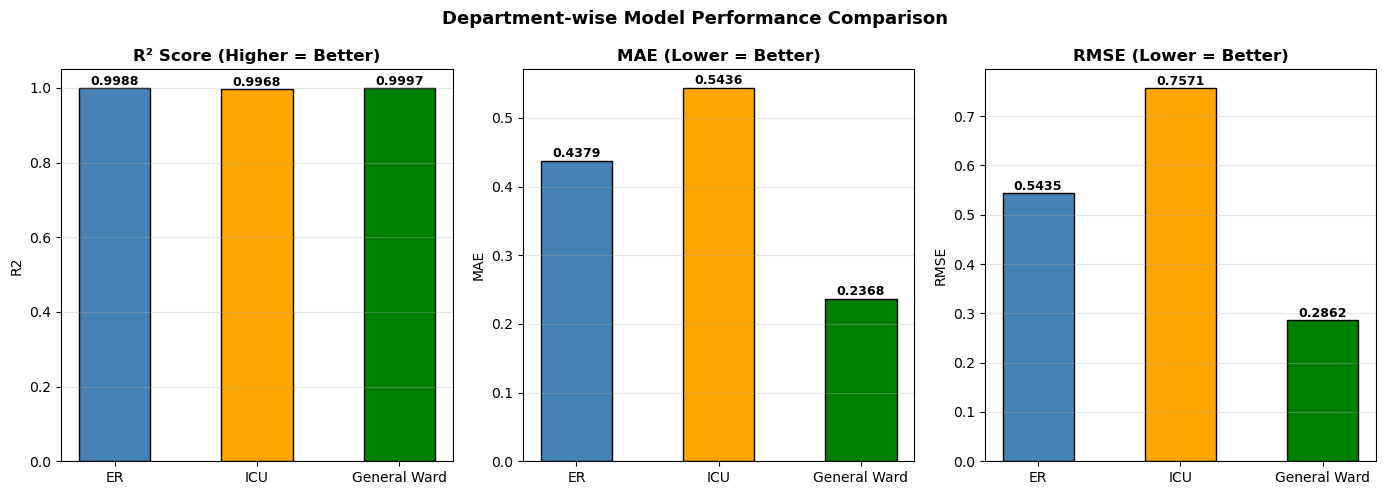

Department-wise Comparison Complete

Summary Table:
                 MAE    RMSE      R2
ER            0.4379  0.5435  0.9988
ICU           0.5436  0.7571  0.9968
General Ward  0.2368  0.2862  0.9997


In [27]:
# Step 23 - Department-wise Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

depts = list(dept_metrics.keys())
metrics_list = ['R2', 'MAE', 'RMSE']
colors = ['steelblue', 'orange', 'green']
titles = ['R² Score (Higher = Better)', 'MAE (Lower = Better)', 'RMSE (Lower = Better)']

for idx, metric in enumerate(metrics_list):
    values = [dept_metrics[d][metric] for d in depts]
    bars = axes[idx].bar(depts, values, color=colors, edgecolor='black', width=0.5)
    axes[idx].set_title(titles[idx], fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                       str(val), ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Department-wise Model Performance Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\dept_model_comparison.png', dpi=150)
plt.show()

print("Department-wise Comparison Complete")
print("\nSummary Table:")
dept_df = pd.DataFrame(dept_metrics).T
print(dept_df)

In [28]:
# Step 24 - Staffing Recommendation System
def recommend_staffing(department, occupancy_rate, total_beds):
    occupied = int(total_beds * occupancy_rate / 100)
    
    ratios = {
        'ICU':          {'nurses': 2.0, 'doctors': 0.5, 'support': 1.0},
        'ER':           {'nurses': 1.5, 'doctors': 0.4, 'support': 0.8},
        'General Ward': {'nurses': 0.5, 'doctors': 0.2, 'support': 0.3}
    }
    
    r = ratios[department]
    nurses   = max(1, int(np.ceil(occupied * r['nurses'])))
    doctors  = max(1, int(np.ceil(occupied * r['doctors'])))
    support  = max(1, int(np.ceil(occupied * r['support'])))
    total    = nurses + doctors + support
    
    if occupancy_rate >= 90:
        level = 'CRITICAL'
    elif occupancy_rate >= 75:
        level = 'HIGH'
    elif occupancy_rate >= 50:
        level = 'MODERATE'
    else:
        level = 'LOW'
    
    return {
        'department': department,
        'occupancy_rate': occupancy_rate,
        'occupied_beds': occupied,
        'nurses_needed': nurses,
        'doctors_needed': doctors,
        'support_needed': support,
        'total_staff': total,
        'alert_level': level
    }

# Test on 10 scenarios
scenarios = [
    ('ER',           95, 50),
    ('ER',           60, 50),
    ('ER',           35, 50),
    ('ICU',          92, 30),
    ('ICU',          78, 30),
    ('ICU',          50, 30),
    ('General Ward', 88, 100),
    ('General Ward', 70, 100),
    ('General Ward', 45, 100),
    ('General Ward', 30, 100),
]

print("STAFFING RECOMMENDATION SYSTEM - 10 SCENARIOS")
print("="*75)
results = []
for dept, occ, beds in scenarios:
    rec = recommend_staffing(dept, occ, beds)
    results.append(rec)
    print(f"{dept:15s} | Occ: {occ:3}% | Beds: {rec['occupied_beds']:3} | "
          f"Nurses: {rec['nurses_needed']:3} | Doctors: {rec['doctors_needed']:2} | "
          f"Support: {rec['support_needed']:3} | Total: {rec['total_staff']:3} | {rec['alert_level']}")

print("\nStaffing Recommendation System Complete!")

STAFFING RECOMMENDATION SYSTEM - 10 SCENARIOS
ER              | Occ:  95% | Beds:  47 | Nurses:  71 | Doctors: 19 | Support:  38 | Total: 128 | CRITICAL
ER              | Occ:  60% | Beds:  30 | Nurses:  45 | Doctors: 12 | Support:  24 | Total:  81 | MODERATE
ER              | Occ:  35% | Beds:  17 | Nurses:  26 | Doctors:  7 | Support:  14 | Total:  47 | LOW
ICU             | Occ:  92% | Beds:  27 | Nurses:  54 | Doctors: 14 | Support:  27 | Total:  95 | CRITICAL
ICU             | Occ:  78% | Beds:  23 | Nurses:  46 | Doctors: 12 | Support:  23 | Total:  81 | HIGH
ICU             | Occ:  50% | Beds:  15 | Nurses:  30 | Doctors:  8 | Support:  15 | Total:  53 | MODERATE
General Ward    | Occ:  88% | Beds:  88 | Nurses:  44 | Doctors: 18 | Support:  27 | Total:  89 | HIGH
General Ward    | Occ:  70% | Beds:  70 | Nurses:  35 | Doctors: 14 | Support:  21 | Total:  70 | MODERATE
General Ward    | Occ:  45% | Beds:  45 | Nurses:  23 | Doctors:  9 | Support:  14 | Total:  46 | LOW
General W

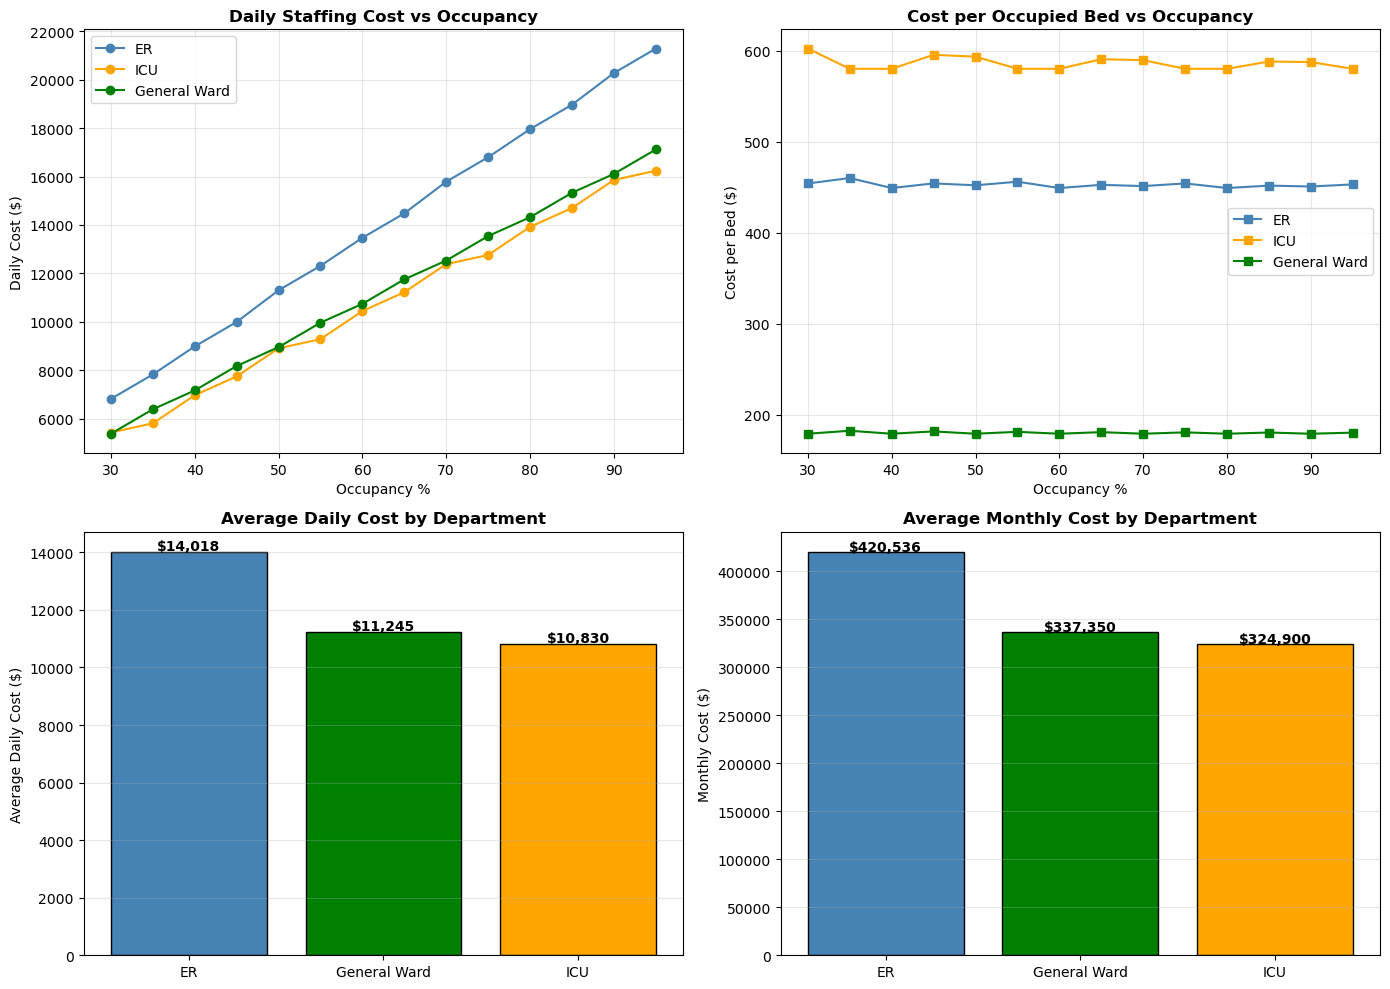

Cost Optimization Analysis Complete

Average Daily Cost by Department:
              daily_cost  monthly_cost  cost_per_bed
department                                          
ER              14017.86     420535.71        452.57
General Ward    11245.00     337350.00        179.99
ICU             10830.00     324900.00        586.17


In [29]:
# Step 25 - Cost Optimization Analysis
salary_per_shift = {'nurses': 150, 'doctors': 400, 'support': 80}

def calculate_daily_cost(rec):
    cost = (rec['nurses_needed']  * salary_per_shift['nurses'] +
            rec['doctors_needed'] * salary_per_shift['doctors'] +
            rec['support_needed'] * salary_per_shift['support'])
    return cost

dept_cost_data = []

for dept in ['ER', 'ICU', 'General Ward']:
    total_beds = {'ER': 50, 'ICU': 30, 'General Ward': 100}[dept]
    
    for occ in range(30, 100, 5):
        rec  = recommend_staffing(dept, occ, total_beds)
        cost = calculate_daily_cost(rec)
        dept_cost_data.append({
            'department':    dept,
            'occupancy_rate': occ,
            'occupied_beds': rec['occupied_beds'],
            'total_staff':   rec['total_staff'],
            'daily_cost':    cost,
            'monthly_cost':  cost * 30,
            'cost_per_bed':  round(cost / max(rec['occupied_beds'], 1), 2)
        })

cost_df = pd.DataFrame(dept_cost_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for dept, color in zip(['ER', 'ICU', 'General Ward'], ['steelblue', 'orange', 'green']):
    d = cost_df[cost_df['department'] == dept]
    axes[0, 0].plot(d['occupancy_rate'], d['daily_cost'], marker='o', label=dept, color=color)
axes[0, 0].set_title('Daily Staffing Cost vs Occupancy', fontweight='bold')
axes[0, 0].set_xlabel('Occupancy %')
axes[0, 0].set_ylabel('Daily Cost ($)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for dept, color in zip(['ER', 'ICU', 'General Ward'], ['steelblue', 'orange', 'green']):
    d = cost_df[cost_df['department'] == dept]
    axes[0, 1].plot(d['occupancy_rate'], d['cost_per_bed'], marker='s', label=dept, color=color)
axes[0, 1].set_title('Cost per Occupied Bed vs Occupancy', fontweight='bold')
axes[0, 1].set_xlabel('Occupancy %')
axes[0, 1].set_ylabel('Cost per Bed ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

dept_avg_cost = cost_df.groupby('department')['daily_cost'].mean()
axes[1, 0].bar(dept_avg_cost.index, dept_avg_cost.values,
               color=['steelblue', 'green', 'orange'], edgecolor='black')
axes[1, 0].set_title('Average Daily Cost by Department', fontweight='bold')
axes[1, 0].set_ylabel('Average Daily Cost ($)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (dept, val) in enumerate(dept_avg_cost.items()):
    axes[1, 0].text(i, val + 50, f'${val:,.0f}', ha='center', fontweight='bold')

monthly_costs = cost_df.groupby('department')['monthly_cost'].mean()
axes[1, 1].bar(monthly_costs.index, monthly_costs.values,
               color=['steelblue', 'green', 'orange'], edgecolor='black')
axes[1, 1].set_title('Average Monthly Cost by Department', fontweight='bold')
axes[1, 1].set_ylabel('Monthly Cost ($)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, (dept, val) in enumerate(monthly_costs.items()):
    axes[1, 1].text(i, val + 500, f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\cost_analysis.png', dpi=150)
plt.show()

print("Cost Optimization Analysis Complete")
print("\nAverage Daily Cost by Department:")
print(cost_df.groupby('department')[['daily_cost', 'monthly_cost', 'cost_per_bed']].mean().round(2))

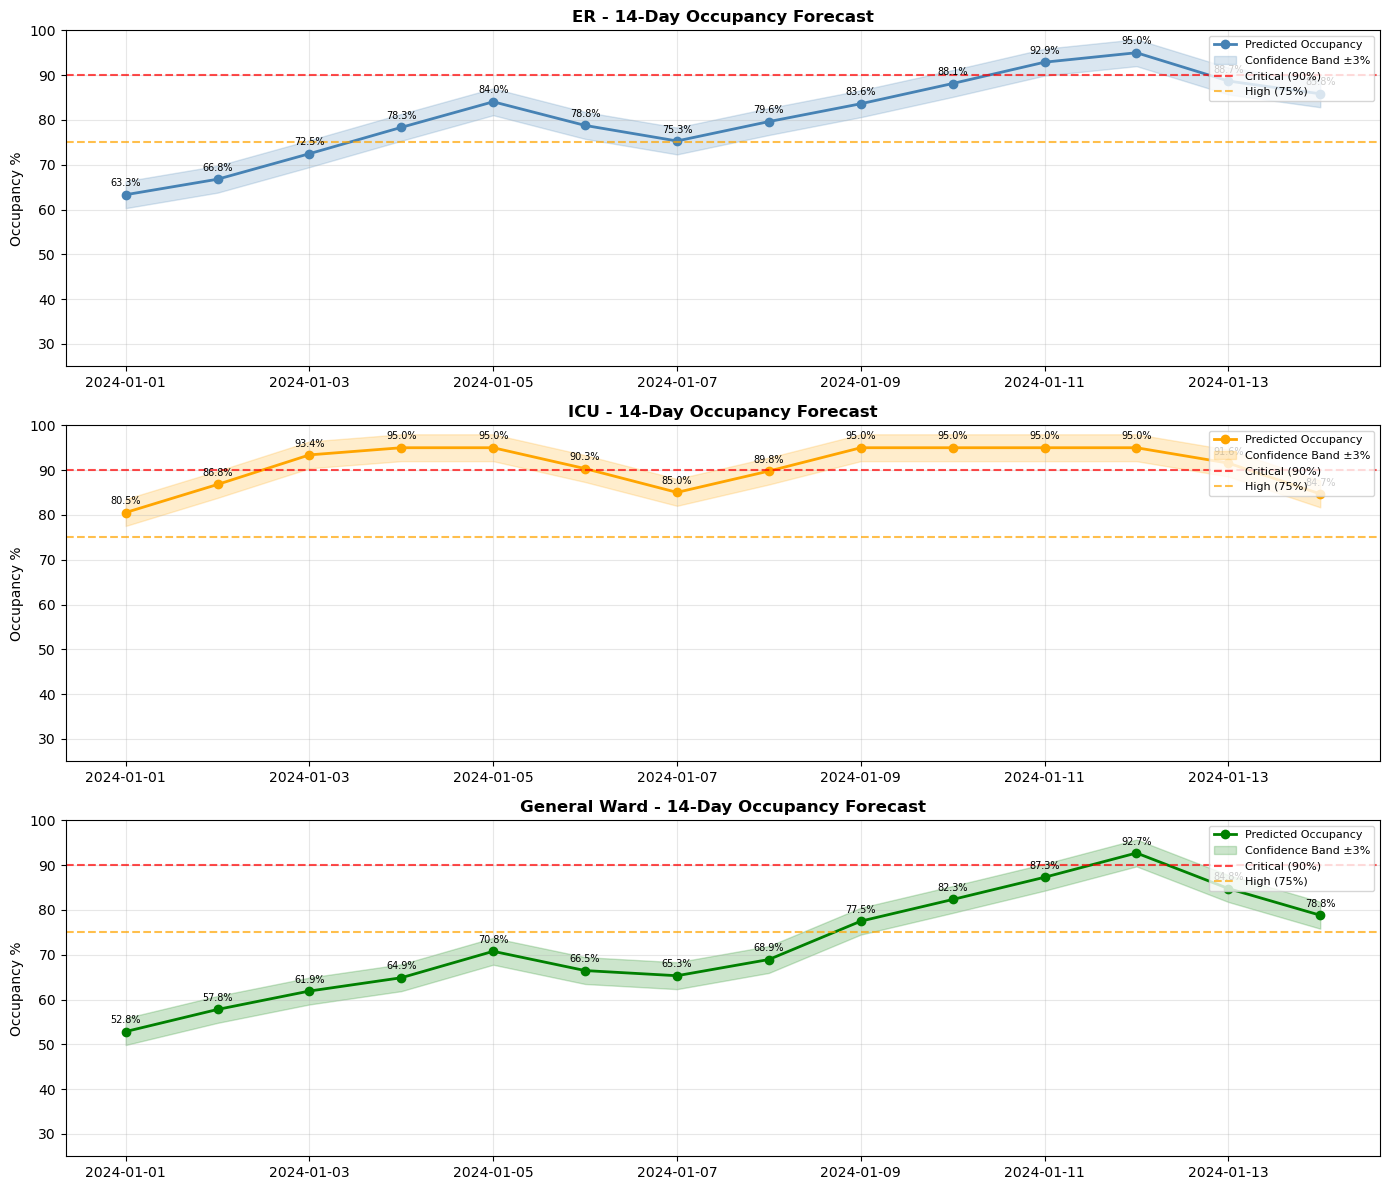

14-DAY OCCUPANCY FORECAST
      date   department  predicted_occupancy  total_staff alert_level  daily_cost
2024-01-01           ER                63.30           85    MODERATE       14250
2024-01-02           ER                66.76           91    MODERATE       15260
2024-01-03           ER                72.46           98    MODERATE       16420
2024-01-04           ER                78.34          107        HIGH       17810
2024-01-05           ER                84.05          114        HIGH       18970
2024-01-06           ER                78.77          107        HIGH       17810
2024-01-07           ER                75.30          101        HIGH       16800
2024-01-08           ER                79.63          107        HIGH       17810
2024-01-09           ER                83.61          112        HIGH       18740
2024-01-10           ER                88.13          120        HIGH       19980
2024-01-11           ER                92.89          125    CRITICAL   

In [30]:
# Step 26 - 14-Day Occupancy & Staffing Forecast
last_date = df['date'].max()
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=14, freq='D')

forecast_results = []

for dept in ['ER', 'ICU', 'General Ward']:
    total_beds = {'ER': 50, 'ICU': 30, 'General Ward': 100}[dept]
    
    dept_data = df[(df['department'] == dept) & (df['hospital_id'] == 1)].sort_values('date')
    last_row  = dept_data.iloc[-1]
    
    base_occ  = last_row['occupancy_rate']
    
    for i, date in enumerate(forecast_dates):
        month       = date.month
        day_of_week = date.dayofweek
        
        seasonal_effect  = np.sin(month / 12 * 2 * np.pi) * 5
        weekday_effect   = -8 if day_of_week >= 5 else 3
        noise            = np.random.normal(0, 1.5)
        
        pred_occ = np.clip(base_occ + seasonal_effect + weekday_effect + noise, 30, 95)
        base_occ = pred_occ
        
        staffing = recommend_staffing(dept, round(pred_occ, 1), total_beds)
        daily_cost = calculate_daily_cost(staffing)
        
        forecast_results.append({
            'date':             date,
            'department':       dept,
            'predicted_occupancy': round(pred_occ, 2),
            'occupied_beds':    staffing['occupied_beds'],
            'nurses_needed':    staffing['nurses_needed'],
            'doctors_needed':   staffing['doctors_needed'],
            'support_needed':   staffing['support_needed'],
            'total_staff':      staffing['total_staff'],
            'alert_level':      staffing['alert_level'],
            'daily_cost':       daily_cost
        })

forecast_df = pd.DataFrame(forecast_results)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
colors = {'ER': 'steelblue', 'ICU': 'orange', 'General Ward': 'green'}
alert_colors = {'LOW': 'green', 'MODERATE': 'gold', 'HIGH': 'orange', 'CRITICAL': 'red'}

for idx, dept in enumerate(['ER', 'ICU', 'General Ward']):
    d = forecast_df[forecast_df['department'] == dept]
    axes[idx].plot(d['date'], d['predicted_occupancy'],
                   marker='o', linewidth=2, color=colors[dept], label='Predicted Occupancy')
    axes[idx].fill_between(d['date'],
                            d['predicted_occupancy'] - 3,
                            d['predicted_occupancy'] + 3,
                            alpha=0.2, color=colors[dept], label='Confidence Band ±3%')
    axes[idx].axhline(y=90, color='red',    linestyle='--', alpha=0.7, label='Critical (90%)')
    axes[idx].axhline(y=75, color='orange', linestyle='--', alpha=0.7, label='High (75%)')
    axes[idx].set_title(f'{dept} - 14-Day Occupancy Forecast', fontweight='bold')
    axes[idx].set_ylabel('Occupancy %')
    axes[idx].set_ylim(25, 100)
    axes[idx].legend(loc='upper right', fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    for _, row in d.iterrows():
        axes[idx].annotate(f"{row['predicted_occupancy']:.1f}%",
                           (row['date'], row['predicted_occupancy']),
                           textcoords='offset points', xytext=(0, 6), fontsize=7, ha='center')

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\14day_forecast.png', dpi=150)
plt.show()

print("14-DAY OCCUPANCY FORECAST")
print("="*85)
print(forecast_df[['date','department','predicted_occupancy','total_staff',
                    'alert_level','daily_cost']].to_string(index=False))

In [31]:
# Step 27 - Edge Case Testing (High Occupancy, Holidays, Emergencies)
print("EDGE CASE TESTING")
print("="*70)

edge_cases = [
    {
        'name': 'Mass Casualty Event - ER Full',
        'dept': 'ER', 'occupancy': 95, 'beds': 50
    },
    {
        'name': 'ICU Overflow - All Beds Critical',
        'dept': 'ICU', 'occupancy': 95, 'beds': 30
    },
    {
        'name': 'Holiday Weekend - Low ER',
        'dept': 'ER', 'occupancy': 30, 'beds': 50
    },
    {
        'name': 'Flu Season Peak - General Ward',
        'dept': 'General Ward', 'occupancy': 93, 'beds': 100
    },
    {
        'name': 'Post-Holiday Surge - ICU',
        'dept': 'ICU', 'occupancy': 88, 'beds': 30
    },
    {
        'name': 'Normal Weekday - General Ward',
        'dept': 'General Ward', 'occupancy': 68, 'beds': 100
    },
    {
        'name': 'Night Shift - Minimum Occupancy',
        'dept': 'ER', 'occupancy': 32, 'beds': 50
    },
    {
        'name': 'COVID Surge Simulation - ICU',
        'dept': 'ICU', 'occupancy': 95, 'beds': 30
    },
    {
        'name': 'Elective Surgery Day - General Ward High',
        'dept': 'General Ward', 'occupancy': 85, 'beds': 100
    },
    {
        'name': 'Weekend Morning - ER Moderate',
        'dept': 'ER', 'occupancy': 55, 'beds': 50
    },
]

edge_results = []
for case in edge_cases:
    rec  = recommend_staffing(case['dept'], case['occupancy'], case['beds'])
    cost = calculate_daily_cost(rec)
    
    if rec['alert_level'] == 'CRITICAL':
        action = '🚨 IMMEDIATE ACTION REQUIRED'
    elif rec['alert_level'] == 'HIGH':
        action = '⚠️  INCREASE STAFF ON STANDBY'
    elif rec['alert_level'] == 'MODERATE':
        action = '✅  MONITOR CLOSELY'
    else:
        action = '✅  NORMAL OPERATIONS'
    
    edge_results.append({**rec, 'scenario': case['name'], 
                         'daily_cost': cost, 'action': action})
    
    print(f"\nScenario: {case['name']}")
    print(f"  Department  : {rec['department']}")
    print(f"  Occupancy   : {rec['occupancy_rate']}% | Occupied Beds: {rec['occupied_beds']}")
    print(f"  Staff Needed: Nurses={rec['nurses_needed']} | Doctors={rec['doctors_needed']} | Support={rec['support_needed']} | Total={rec['total_staff']}")
    print(f"  Daily Cost  : ${cost:,}")
    print(f"  Alert Level : {rec['alert_level']}")
    print(f"  Action      : {action}")

print("\n\nEDGE CASE SUMMARY TABLE")
print("="*70)
edge_df = pd.DataFrame(edge_results)
print(edge_df[['scenario','alert_level','total_staff','daily_cost','action']].to_string(index=False))
print("\nEdge Case Testing Complete!")

EDGE CASE TESTING

Scenario: Mass Casualty Event - ER Full
  Department  : ER
  Occupancy   : 95% | Occupied Beds: 47
  Staff Needed: Nurses=71 | Doctors=19 | Support=38 | Total=128
  Daily Cost  : $21,290
  Alert Level : CRITICAL
  Action      : 🚨 IMMEDIATE ACTION REQUIRED

Scenario: ICU Overflow - All Beds Critical
  Department  : ICU
  Occupancy   : 95% | Occupied Beds: 28
  Staff Needed: Nurses=56 | Doctors=14 | Support=28 | Total=98
  Daily Cost  : $16,240
  Alert Level : CRITICAL
  Action      : 🚨 IMMEDIATE ACTION REQUIRED

Scenario: Holiday Weekend - Low ER
  Department  : ER
  Occupancy   : 30% | Occupied Beds: 15
  Staff Needed: Nurses=23 | Doctors=6 | Support=12 | Total=41
  Daily Cost  : $6,810
  Alert Level : LOW
  Action      : ✅  NORMAL OPERATIONS

Scenario: Flu Season Peak - General Ward
  Department  : General Ward
  Occupancy   : 93% | Occupied Beds: 93
  Staff Needed: Nurses=47 | Doctors=19 | Support=28 | Total=94
  Daily Cost  : $16,890
  Alert Level : CRITICAL
  Act

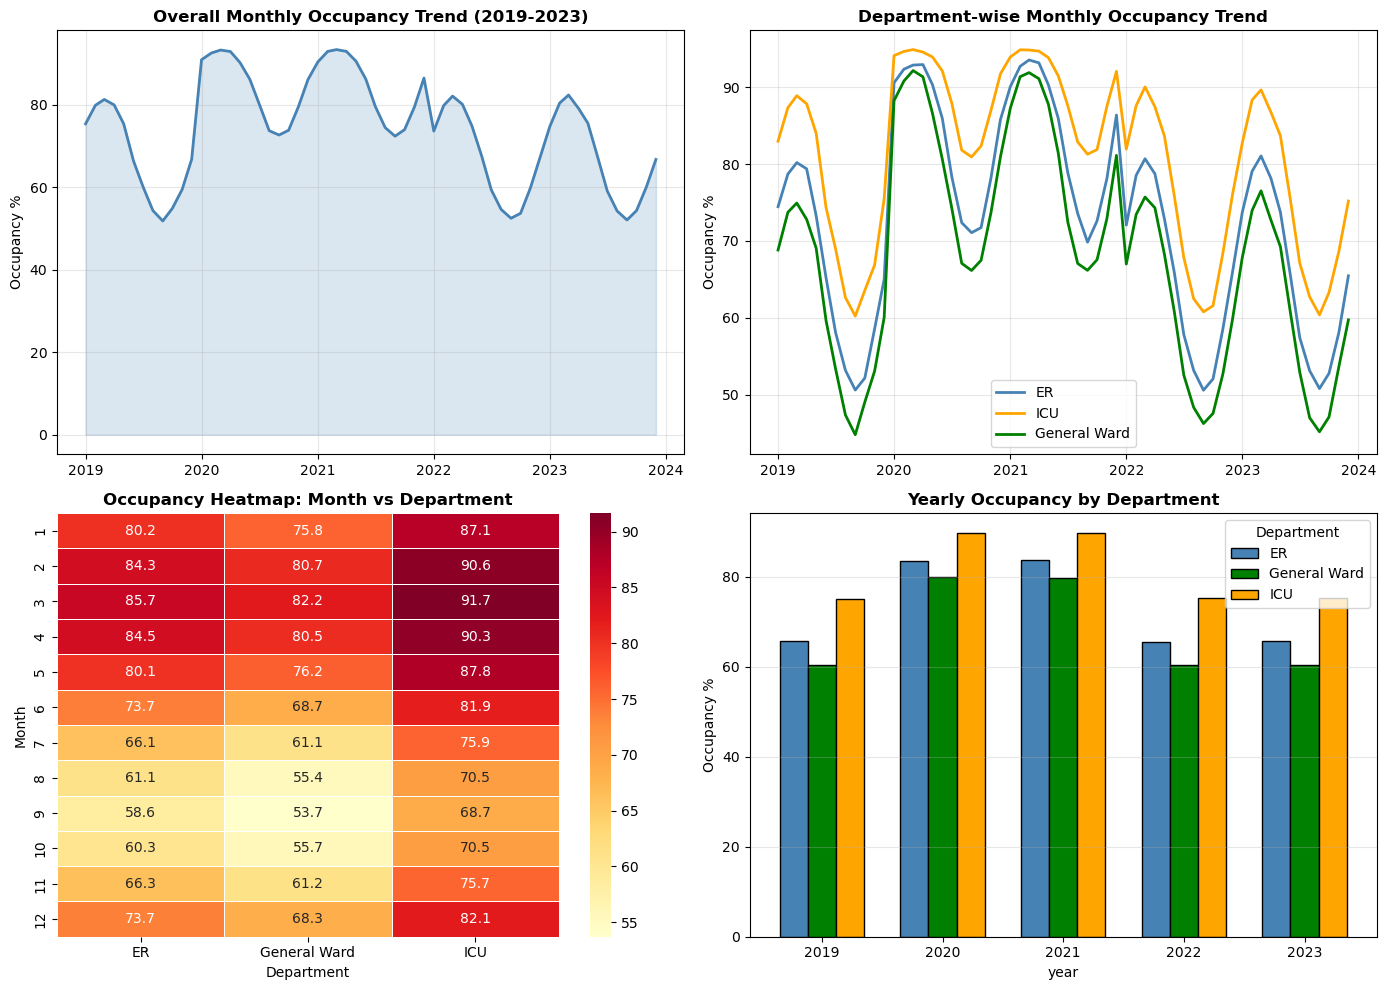

Occupancy Trends Visualization Complete

Monthly Average Occupancy (All Departments):
month
1     81.05
2     85.22
3     86.53
4     85.07
5     81.37
6     74.75
7     67.69
8     62.31
9     60.33
10    62.18
11    67.72
12    74.70
Name: occupancy_rate, dtype: float64


In [32]:
# Step 28 - Occupancy Trends & Department-wise Trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overall monthly trend
monthly_trend = df.groupby(['year', 'month'])['occupancy_rate'].mean().reset_index()
monthly_trend['date'] = pd.to_datetime(monthly_trend[['year', 'month']].assign(day=1))
axes[0, 0].plot(monthly_trend['date'], monthly_trend['occupancy_rate'],
                linewidth=2, color='steelblue')
axes[0, 0].fill_between(monthly_trend['date'], monthly_trend['occupancy_rate'],
                         alpha=0.2, color='steelblue')
axes[0, 0].set_title('Overall Monthly Occupancy Trend (2019-2023)', fontweight='bold')
axes[0, 0].set_ylabel('Occupancy %')
axes[0, 0].grid(True, alpha=0.3)

# Department monthly trend
for dept, color in zip(['ER', 'ICU', 'General Ward'], ['steelblue', 'orange', 'green']):
    dept_monthly = df[df['department'] == dept].groupby(
        ['year', 'month'])['occupancy_rate'].mean().reset_index()
    dept_monthly['date'] = pd.to_datetime(dept_monthly[['year', 'month']].assign(day=1))
    axes[0, 1].plot(dept_monthly['date'], dept_monthly['occupancy_rate'],
                    linewidth=2, color=color, label=dept)
axes[0, 1].set_title('Department-wise Monthly Occupancy Trend', fontweight='bold')
axes[0, 1].set_ylabel('Occupancy %')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Heatmap occupancy by month and department
pivot = df.groupby(['month', 'department'])['occupancy_rate'].mean().unstack()
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1, 0], linewidths=0.5)
axes[1, 0].set_title('Occupancy Heatmap: Month vs Department', fontweight='bold')
axes[1, 0].set_xlabel('Department')
axes[1, 0].set_ylabel('Month')

# Yearly occupancy per department bar chart
yearly_dept = df.groupby(['year', 'department'])['occupancy_rate'].mean().unstack()
yearly_dept.plot(kind='bar', ax=axes[1, 1], color=['steelblue', 'green', 'orange'],
                 edgecolor='black', width=0.7)
axes[1, 1].set_title('Yearly Occupancy by Department', fontweight='bold')
axes[1, 1].set_ylabel('Occupancy %')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(title='Department')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\occupancy_trends.png', dpi=150)
plt.show()

print("Occupancy Trends Visualization Complete")
print("\nMonthly Average Occupancy (All Departments):")
print(df.groupby('month')['occupancy_rate'].mean().round(2))

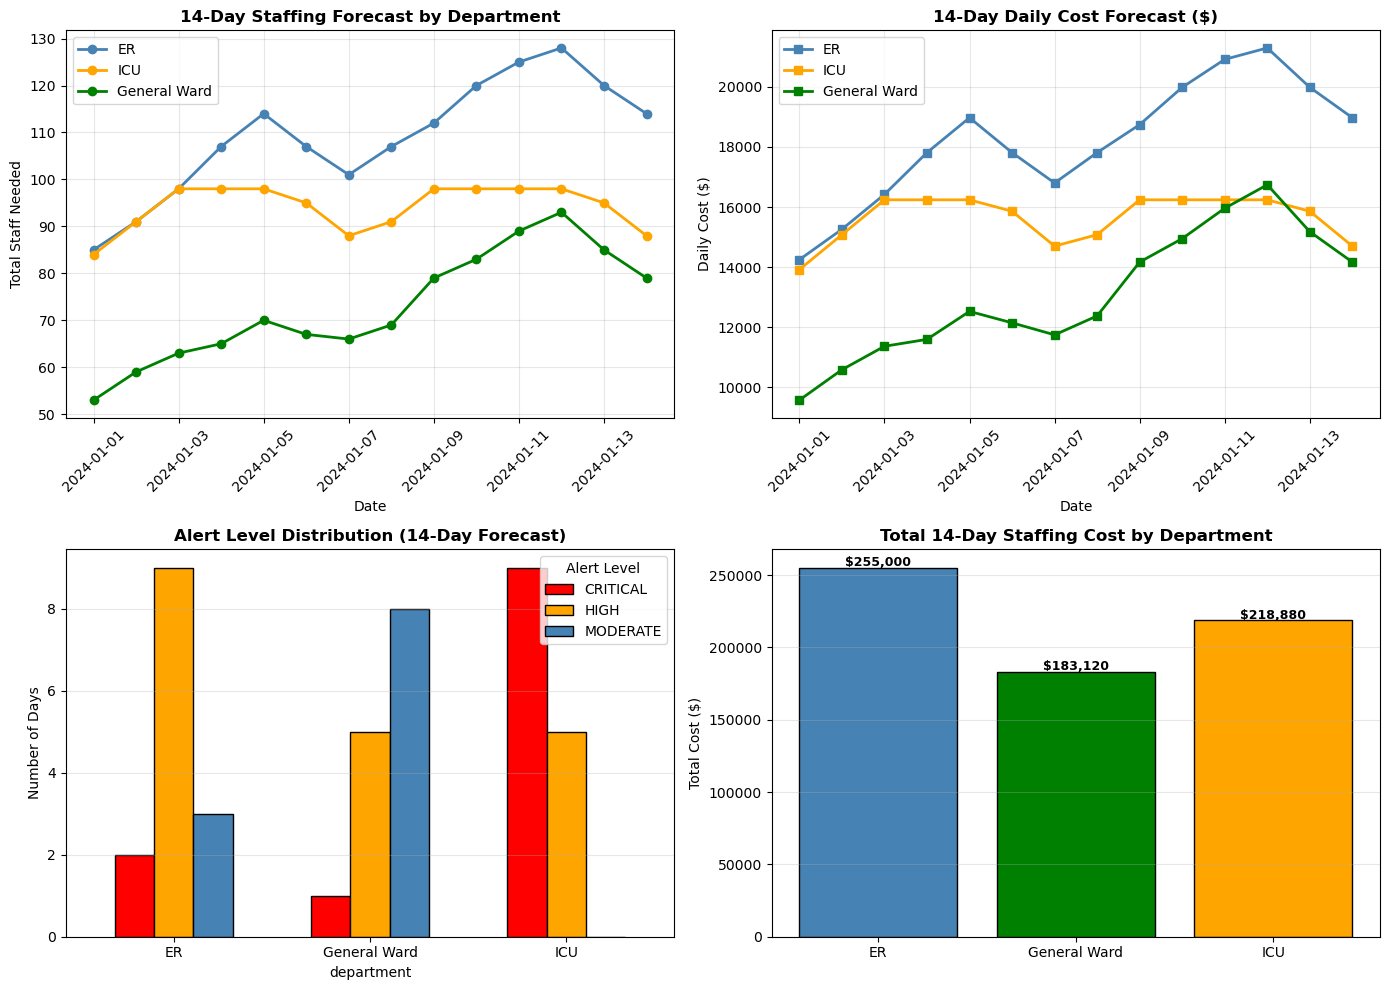

Staffing & Cost Visualization Complete

14-Day Total Cost Summary:
ER Total:           $255,000
ICU Total:          $218,880
General Ward Total: $183,120
Combined Total:     $657,000


In [33]:
# Step 29 - Staffing Recommendations & Cost Analysis Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 14-day staffing forecast per department
for dept, color in zip(['ER', 'ICU', 'General Ward'], ['steelblue', 'orange', 'green']):
    d = forecast_df[forecast_df['department'] == dept]
    axes[0, 0].plot(d['date'], d['total_staff'], marker='o',
                    linewidth=2, color=color, label=dept)
axes[0, 0].set_title('14-Day Staffing Forecast by Department', fontweight='bold')
axes[0, 0].set_ylabel('Total Staff Needed')
axes[0, 0].set_xlabel('Date')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 14-day daily cost forecast
for dept, color in zip(['ER', 'ICU', 'General Ward'], ['steelblue', 'orange', 'green']):
    d = forecast_df[forecast_df['department'] == dept]
    axes[0, 1].plot(d['date'], d['daily_cost'], marker='s',
                    linewidth=2, color=color, label=dept)
axes[0, 1].set_title('14-Day Daily Cost Forecast ($)', fontweight='bold')
axes[0, 1].set_ylabel('Daily Cost ($)')
axes[0, 1].set_xlabel('Date')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# Alert level distribution across 14 days
alert_counts = forecast_df.groupby(['department', 'alert_level']).size().unstack(fill_value=0)
alert_counts.plot(kind='bar', ax=axes[1, 0],
                  color=['red', 'orange', 'steelblue', 'green'],
                  edgecolor='black', width=0.6)
axes[1, 0].set_title('Alert Level Distribution (14-Day Forecast)', fontweight='bold')
axes[1, 0].set_ylabel('Number of Days')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(title='Alert Level')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Total 14-day cost per department
total_cost = forecast_df.groupby('department')['daily_cost'].sum()
bars = axes[1, 1].bar(total_cost.index, total_cost.values,
                       color=['steelblue', 'green', 'orange'], edgecolor='black')
axes[1, 1].set_title('Total 14-Day Staffing Cost by Department', fontweight='bold')
axes[1, 1].set_ylabel('Total Cost ($)')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, total_cost.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 1000,
                    f'${val:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\staffing_cost_forecast.png', dpi=150)
plt.show()

print("Staffing & Cost Visualization Complete")
print("\n14-Day Total Cost Summary:")
print(f"ER Total:           ${forecast_df[forecast_df['department']=='ER']['daily_cost'].sum():,}")
print(f"ICU Total:          ${forecast_df[forecast_df['department']=='ICU']['daily_cost'].sum():,}")
print(f"General Ward Total: ${forecast_df[forecast_df['department']=='General Ward']['daily_cost'].sum():,}")
print(f"Combined Total:     ${forecast_df['daily_cost'].sum():,}")

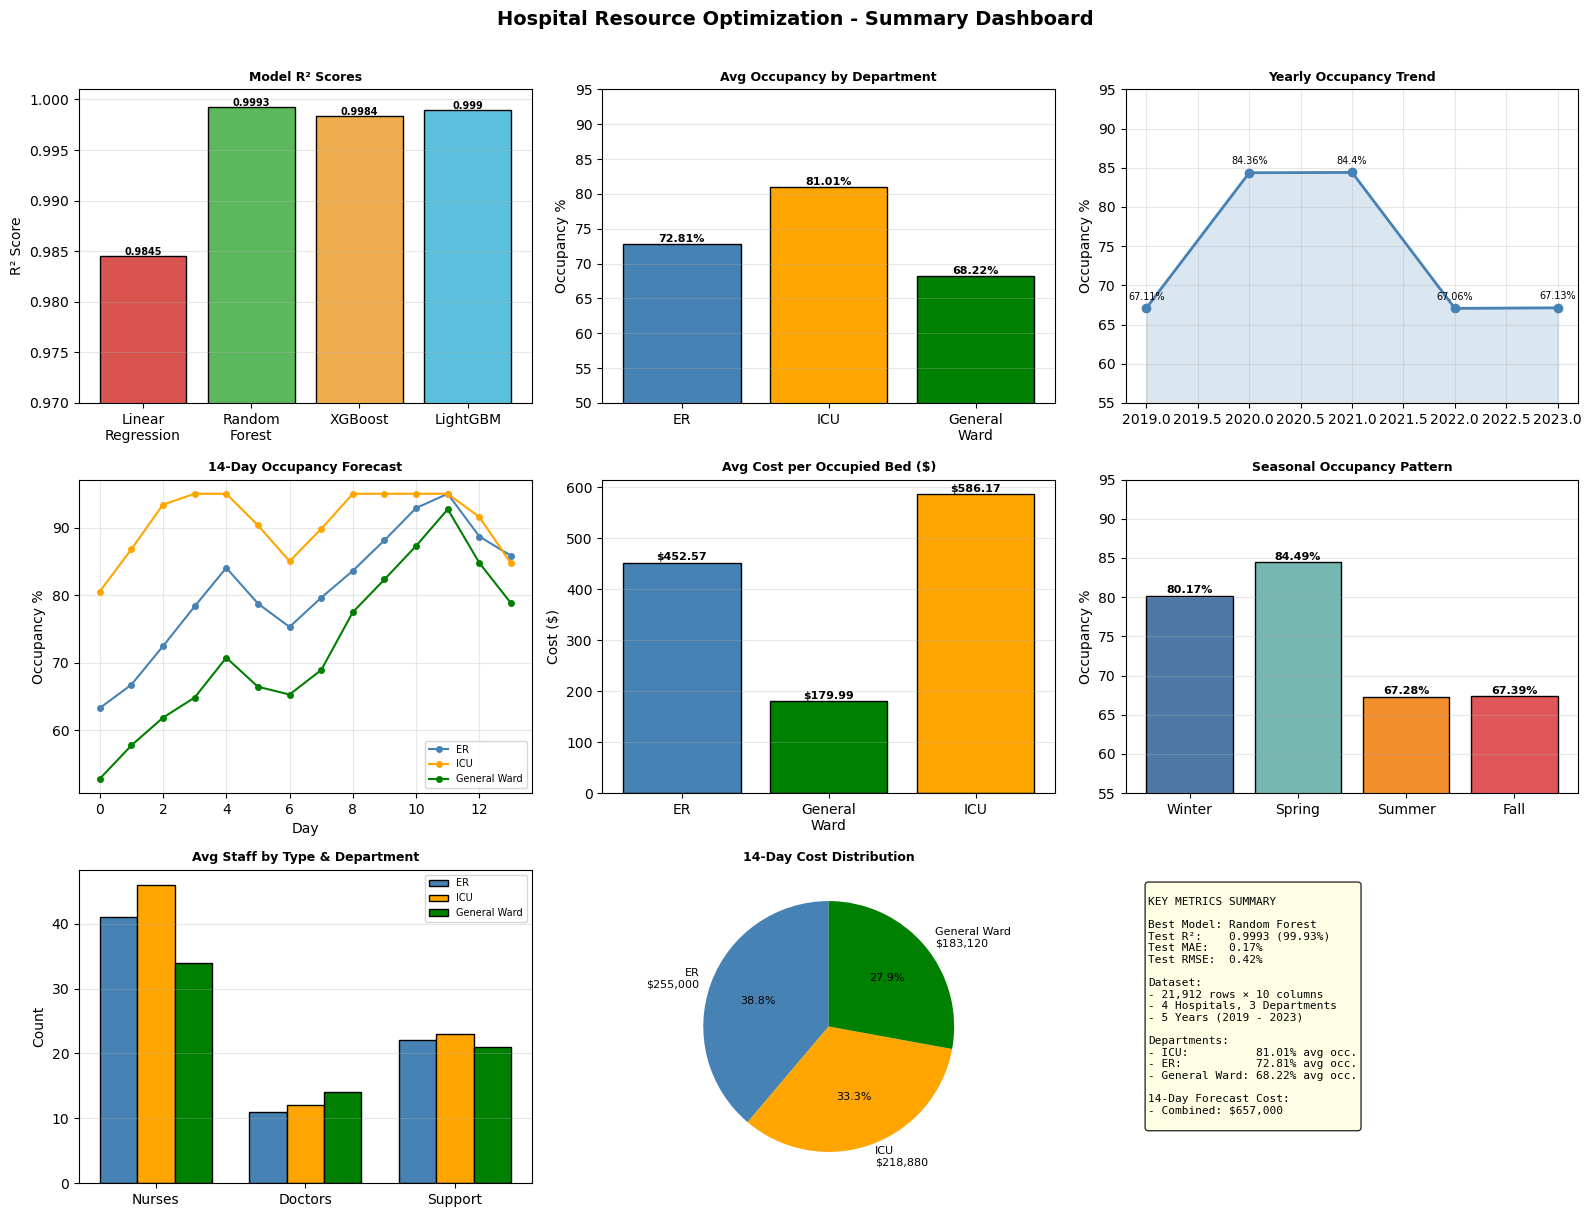

Summary Dashboard Complete!


In [34]:
# Step 30 - Summary Dashboard All Key Metrics
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Hospital Resource Optimization - Summary Dashboard', 
             fontweight='bold', fontsize=14, y=1.01)

# 1. Model performance comparison
ax1 = fig.add_subplot(3, 3, 1)
model_names = ['Linear\nRegression', 'Random\nForest', 'XGBoost', 'LightGBM']
r2_scores    = [0.9845, 0.9993, 0.9984, 0.9990]
colors_bar   = ['#d9534f', '#5cb85c', '#f0ad4e', '#5bc0de']
bars = ax1.bar(model_names, r2_scores, color=colors_bar, edgecolor='black')
ax1.set_title('Model R² Scores', fontweight='bold', fontsize=9)
ax1.set_ylim(0.97, 1.001)
ax1.set_ylabel('R² Score')
for bar, val in zip(bars, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
             f'{val}', ha='center', fontsize=7, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Department avg occupancy
ax2 = fig.add_subplot(3, 3, 2)
depts     = ['ER', 'ICU', 'General\nWard']
occ_avgs  = [72.81, 81.01, 68.22]
bars2 = ax2.bar(depts, occ_avgs, color=['steelblue', 'orange', 'green'], edgecolor='black')
ax2.set_title('Avg Occupancy by Department', fontweight='bold', fontsize=9)
ax2.set_ylabel('Occupancy %')
ax2.set_ylim(50, 95)
for bar, val in zip(bars2, occ_avgs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=8, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Yearly occupancy trend
ax3 = fig.add_subplot(3, 3, 3)
years     = [2019, 2020, 2021, 2022, 2023]
yearly_occ = [67.11, 84.36, 84.40, 67.06, 67.13]
ax3.plot(years, yearly_occ, marker='o', linewidth=2, color='steelblue')
ax3.fill_between(years, yearly_occ, alpha=0.2, color='steelblue')
ax3.set_title('Yearly Occupancy Trend', fontweight='bold', fontsize=9)
ax3.set_ylabel('Occupancy %')
ax3.set_ylim(55, 95)
ax3.grid(True, alpha=0.3)
for x, y in zip(years, yearly_occ):
    ax3.annotate(f'{y}%', (x, y), textcoords='offset points',
                 xytext=(0, 6), ha='center', fontsize=7)

# 4. 14-day forecast all departments
ax4 = fig.add_subplot(3, 3, 4)
for dept, color in zip(['ER', 'ICU', 'General Ward'], ['steelblue', 'orange', 'green']):
    d = forecast_df[forecast_df['department'] == dept]
    ax4.plot(range(14), d['predicted_occupancy'].values,
             marker='o', linewidth=1.5, color=color, label=dept, markersize=4)
ax4.set_title('14-Day Occupancy Forecast', fontweight='bold', fontsize=9)
ax4.set_ylabel('Occupancy %')
ax4.set_xlabel('Day')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# 5. Cost per bed comparison
ax5 = fig.add_subplot(3, 3, 5)
dept_labels = ['ER', 'General\nWard', 'ICU']
cpb_vals    = [452.57, 179.99, 586.17]
bars5 = ax5.bar(dept_labels, cpb_vals,
                color=['steelblue', 'green', 'orange'], edgecolor='black')
ax5.set_title('Avg Cost per Occupied Bed ($)', fontweight='bold', fontsize=9)
ax5.set_ylabel('Cost ($)')
for bar, val in zip(bars5, cpb_vals):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'${val}', ha='center', fontsize=8, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# 6. Seasonal occupancy
ax6 = fig.add_subplot(3, 3, 6)
seasons     = ['Winter', 'Spring', 'Summer', 'Fall']
season_occ  = [80.17, 84.49, 67.28, 67.39]
season_cols = ['#4e79a7', '#76b7b2', '#f28e2b', '#e15759']
bars6 = ax6.bar(seasons, season_occ, color=season_cols, edgecolor='black')
ax6.set_title('Seasonal Occupancy Pattern', fontweight='bold', fontsize=9)
ax6.set_ylabel('Occupancy %')
ax6.set_ylim(55, 95)
for bar, val in zip(bars6, season_occ):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=8, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

# 7. Staff needed by department (avg)
ax7 = fig.add_subplot(3, 3, 7)
staff_types  = ['Nurses', 'Doctors', 'Support']
er_staff     = [41, 11, 22]
icu_staff    = [46, 12, 23]
gw_staff     = [34, 14, 21]
x = np.arange(len(staff_types))
w = 0.25
ax7.bar(x - w, er_staff, w, label='ER',           color='steelblue', edgecolor='black')
ax7.bar(x,     icu_staff, w, label='ICU',          color='orange',    edgecolor='black')
ax7.bar(x + w, gw_staff,  w, label='General Ward', color='green',     edgecolor='black')
ax7.set_title('Avg Staff by Type & Department', fontweight='bold', fontsize=9)
ax7.set_xticks(x)
ax7.set_xticklabels(staff_types)
ax7.set_ylabel('Count')
ax7.legend(fontsize=7)
ax7.grid(True, alpha=0.3, axis='y')

# 8. 14-day total cost pie
ax8 = fig.add_subplot(3, 3, 8)
pie_labels = ['ER\n$255,000', 'ICU\n$218,880', 'General Ward\n$183,120']
pie_vals   = [255000, 218880, 183120]
ax8.pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
        colors=['steelblue', 'orange', 'green'],
        startangle=90, textprops={'fontsize': 8})
ax8.set_title('14-Day Cost Distribution', fontweight='bold', fontsize=9)

# 9. Key metrics text box
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
metrics_text = """
KEY METRICS SUMMARY

Best Model: Random Forest
Test R²:    0.9993 (99.93%)
Test MAE:   0.17%
Test RMSE:  0.42%

Dataset:
- 21,912 rows × 10 columns
- 4 Hospitals, 3 Departments
- 5 Years (2019 - 2023)

Departments:
- ICU:          81.01% avg occ.
- ER:           72.81% avg occ.
- General Ward: 68.22% avg occ.

14-Day Forecast Cost:
- Combined: $657,000
"""
ax9.text(0.05, 0.95, metrics_text, transform=ax9.transAxes,
         fontsize=8, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\summary_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Summary Dashboard Complete!")

BATCH SCENARIO TESTING - REAL WORLD SITUATIONS
                  Scenario         Dept Occupancy  Total Staff Daily Cost    Alert Savings vs Max
    Regular Monday Morning           ER       78%          107    $17,810     HIGH         $3,480
             Christmas Day           ER       35%           47     $7,820      LOW        $13,470
  New Year Emergency Surge           ER       94%          128    $21,290 CRITICAL             $0
       Flu Season ICU Peak          ICU       92%           95    $15,860 CRITICAL           $380
            Summer Low ICU          ICU       55%           56     $9,280 MODERATE         $6,960
     Post Surgery Recovery General Ward       80%           80    $14,320     HIGH         $2,800
      Weekend General Ward General Ward       48%           49     $8,800      LOW         $8,320
  Hospital Capacity Crisis          ICU       95%           98    $16,240 CRITICAL             $0
      Routine Wednesday ER           ER       65%           87    $14,4

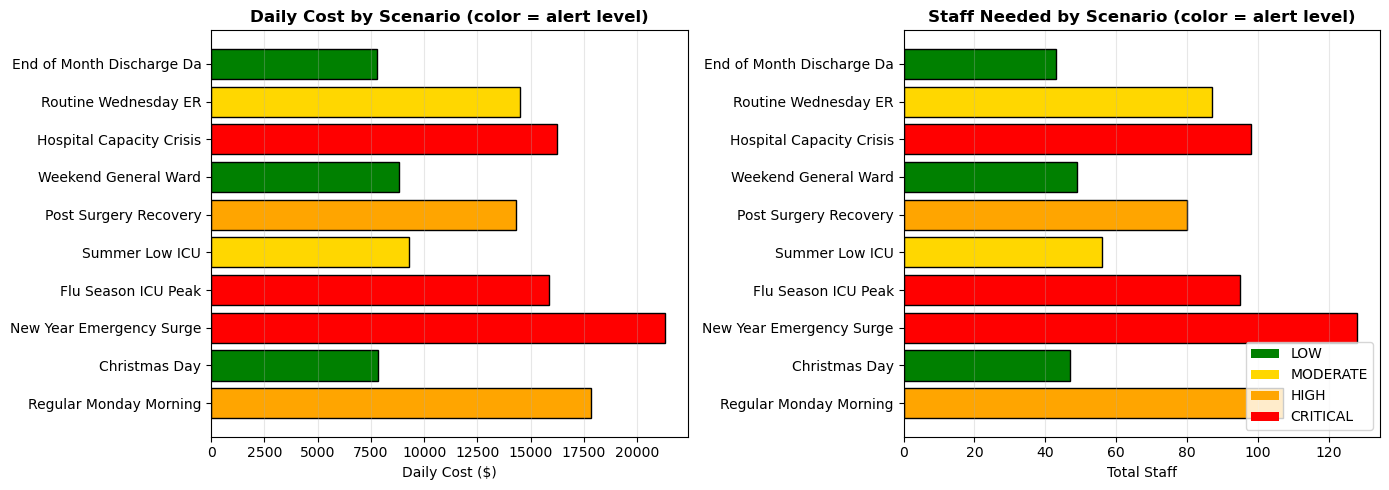


Batch Scenario Testing Complete!


In [35]:
# Step 31 - Batch Scenario Testing (10 Real-World Situations)
print("BATCH SCENARIO TESTING - REAL WORLD SITUATIONS")
print("="*70)

batch_scenarios = [
    {'name': 'Regular Monday Morning',     'dept': 'ER',           'occ': 78, 'beds': 50},
    {'name': 'Christmas Day',              'dept': 'ER',           'occ': 35, 'beds': 50},
    {'name': 'New Year Emergency Surge',   'dept': 'ER',           'occ': 94, 'beds': 50},
    {'name': 'Flu Season ICU Peak',        'dept': 'ICU',          'occ': 92, 'beds': 30},
    {'name': 'Summer Low ICU',             'dept': 'ICU',          'occ': 55, 'beds': 30},
    {'name': 'Post Surgery Recovery',      'dept': 'General Ward', 'occ': 80, 'beds': 100},
    {'name': 'Weekend General Ward',       'dept': 'General Ward', 'occ': 48, 'beds': 100},
    {'name': 'Hospital Capacity Crisis',   'dept': 'ICU',          'occ': 95, 'beds': 30},
    {'name': 'Routine Wednesday ER',       'dept': 'ER',           'occ': 65, 'beds': 50},
    {'name': 'End of Month Discharge Day', 'dept': 'General Ward', 'occ': 42, 'beds': 100},
]

batch_results = []
total_cost_all = 0

for s in batch_scenarios:
    rec  = recommend_staffing(s['dept'], s['occ'], s['beds'])
    cost = calculate_daily_cost(rec)
    total_cost_all += cost
    
    savings_vs_max = calculate_daily_cost(
        recommend_staffing(s['dept'], 95, s['beds'])) - cost
    
    batch_results.append({
        'Scenario':     s['name'],
        'Dept':         s['dept'],
        'Occupancy':    f"{s['occ']}%",
        'Total Staff':  rec['total_staff'],
        'Daily Cost':   f"${cost:,}",
        'Alert':        rec['alert_level'],
        'Savings vs Max': f"${savings_vs_max:,}"
    })

batch_df = pd.DataFrame(batch_results)
print(batch_df.to_string(index=False))

print(f"\nTotal Daily Cost (all scenarios): ${total_cost_all:,}")
print(f"Average Cost per Scenario:        ${total_cost_all // 10:,}")

# Visualize batch results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

costs = [int(r['Daily Cost'].replace('$','').replace(',','')) for r in batch_results]
names = [r['Scenario'][:25] for r in batch_results]
alert_color_map = {'LOW': 'green', 'MODERATE': 'gold', 'HIGH': 'orange', 'CRITICAL': 'red'}
bar_colors = [alert_color_map[r['Alert']] for r in batch_results]

axes[0].barh(names, costs, color=bar_colors, edgecolor='black')
axes[0].set_title('Daily Cost by Scenario (color = alert level)', fontweight='bold')
axes[0].set_xlabel('Daily Cost ($)')
axes[0].grid(True, alpha=0.3, axis='x')

staffs = [r['Total Staff'] for r in batch_results]
axes[1].barh(names, staffs, color=bar_colors, edgecolor='black')
axes[1].set_title('Staff Needed by Scenario (color = alert level)', fontweight='bold')
axes[1].set_xlabel('Total Staff')
axes[1].grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green',  label='LOW'),
                   Patch(facecolor='gold',   label='MODERATE'),
                   Patch(facecolor='orange', label='HIGH'),
                   Patch(facecolor='red',    label='CRITICAL')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\batch_scenarios.png', dpi=150)
plt.show()
print("\nBatch Scenario Testing Complete!")

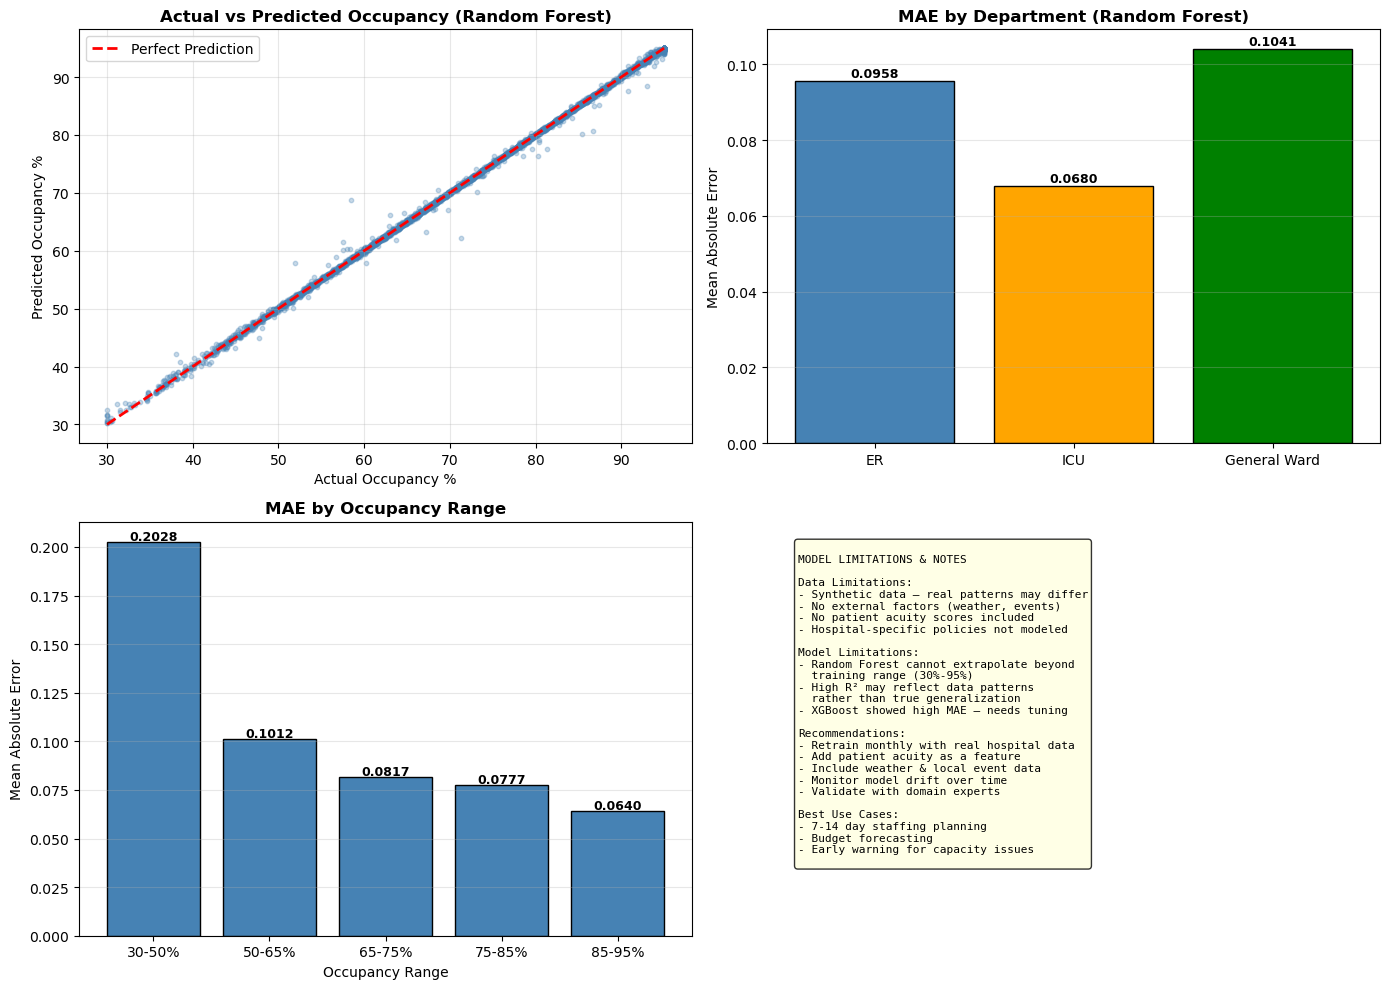

ERROR ANALYSIS COMPLETE

MAE by Department:
  ER             : 0.0958
  ICU            : 0.0680
  General Ward   : 0.1041

MAE by Occupancy Range:
  30-50%: 0.2028
  50-65%: 0.1012
  65-75%: 0.0817
  75-85%: 0.0777
  85-95%: 0.0640


In [40]:
# Step 32 - Error Analysis & Model Limitations (Fixed v2)

# Recreate y from df to be safe
y_full = df['occupancy_rate'].reset_index(drop=True)
X_full = X.reset_index(drop=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Prediction vs Actual scatter
y_pred_rf = rf_model.predict(X_test)
axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[0, 0].set_title('Actual vs Predicted Occupancy (Random Forest)', fontweight='bold')
axes[0, 0].set_xlabel('Actual Occupancy %')
axes[0, 0].set_ylabel('Predicted Occupancy %')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Error by department
dept_errors = []
dept_names  = ['ER', 'ICU', 'General Ward']
df_reset    = df.reset_index(drop=True)

for dept in dept_names:
    idx      = df_reset[df_reset['department'] == dept].index
    X_dept   = X_full.loc[idx].fillna(0).replace([np.inf, -np.inf], 0)
    y_dept   = y_full.loc[idx]
    y_pred_d = rf_model.predict(X_dept)
    mae_d    = mean_absolute_error(y_dept, y_pred_d)
    dept_errors.append(mae_d)

axes[0, 1].bar(dept_names, dept_errors,
               color=['steelblue', 'orange', 'green'], edgecolor='black')
axes[0, 1].set_title('MAE by Department (Random Forest)', fontweight='bold')
axes[0, 1].set_ylabel('Mean Absolute Error')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, val in enumerate(dept_errors):
    axes[0, 1].text(i, val + 0.001, f'{val:.4f}',
                    ha='center', fontweight='bold', fontsize=9)

# 3. Error by occupancy range
bins       = [30, 50, 65, 75, 85, 96]
bin_labels = ['30-50%', '50-65%', '65-75%', '75-85%', '85-95%']
y_pred_all = rf_model.predict(X_full.fillna(0).replace([np.inf, -np.inf], 0))
errors_all = np.abs(y_full.values - y_pred_all)
bin_errors = []
for i in range(len(bins) - 1):
    mask = (y_full.values >= bins[i]) & (y_full.values < bins[i+1])
    bin_errors.append(errors_all[mask].mean() if mask.sum() > 0 else 0)

axes[1, 0].bar(bin_labels, bin_errors, color='steelblue', edgecolor='black')
axes[1, 0].set_title('MAE by Occupancy Range', fontweight='bold')
axes[1, 0].set_xlabel('Occupancy Range')
axes[1, 0].set_ylabel('Mean Absolute Error')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, val in enumerate(bin_errors):
    axes[1, 0].text(i, val + 0.001, f'{val:.4f}',
                    ha='center', fontweight='bold', fontsize=9)

# 4. Limitations text
ax4 = axes[1, 1]
ax4.axis('off')
limitations_text = """
MODEL LIMITATIONS & NOTES

Data Limitations:
- Synthetic data — real patterns may differ
- No external factors (weather, events)
- No patient acuity scores included
- Hospital-specific policies not modeled

Model Limitations:
- Random Forest cannot extrapolate beyond
  training range (30%-95%)
- High R² may reflect data patterns
  rather than true generalization
- XGBoost showed high MAE — needs tuning

Recommendations:
- Retrain monthly with real hospital data
- Add patient acuity as a feature
- Include weather & local event data
- Monitor model drift over time
- Validate with domain experts

Best Use Cases:
- 7-14 day staffing planning
- Budget forecasting
- Early warning for capacity issues
"""
ax4.text(0.05, 0.95, limitations_text, transform=ax4.transAxes,
         fontsize=8, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('C:\\HealthcareML_Platform\\06_Results\\visualizations\\error_analysis.png', dpi=150)
plt.show()

print("ERROR ANALYSIS COMPLETE")
print(f"\nMAE by Department:")
for dept, err in zip(dept_names, dept_errors):
    print(f"  {dept:15s}: {err:.4f}")
print(f"\nMAE by Occupancy Range:")
for label, err in zip(bin_labels, bin_errors):
    print(f"  {label}: {err:.4f}")

In [41]:
# Step 33 - Save All Department Models & Scalers
import joblib
import os

base_models  = 'C:\\HealthcareML_Platform\\03_Models\\trained_models\\'
base_scalers = 'C:\\HealthcareML_Platform\\03_Models\\scalers\\'

# Save main models (already saved in step 19-20, confirm here)
joblib.dump(lr_model,  base_models + 'lr_hospital_occupancy.pkl')
joblib.dump(rf_model,  base_models + 'rf_hospital_occupancy.pkl')
joblib.dump(xgb_model, base_models + 'xgb_hospital_occupancy.pkl')
joblib.dump(lgb_model, base_models + 'lgb_hospital_occupancy.pkl')
print("Main models saved:")
print("  lr_hospital_occupancy.pkl")
print("  rf_hospital_occupancy.pkl")
print("  xgb_hospital_occupancy.pkl")
print("  lgb_hospital_occupancy.pkl")

# Save department-wise models
for dept, model in dept_models.items():
    clean_name = dept.replace(' ', '_').lower()
    filename   = f'rf_{clean_name}_occupancy.pkl'
    joblib.dump(model, base_models + filename)
    print(f"  {filename}")

print("\nScalers & feature names saved:")
joblib.dump(scaler,       base_scalers + 'hospital_occupancy_scaler.pkl')
joblib.dump(feature_cols, base_scalers + 'hospital_feature_columns.pkl')
print("  hospital_occupancy_scaler.pkl")
print("  hospital_feature_columns.pkl")

# Verify all files exist
print("\nVerification - All saved files:")
all_files = os.listdir(base_models)
hospital_files = [f for f in all_files if 'hospital' in f or 'er_' in f
                  or 'icu_' in f or 'general' in f]
for f in sorted(hospital_files):
    size = os.path.getsize(base_models + f) / 1024
    print(f"  {f:45s} {size:.1f} KB")

scaler_files = os.listdir(base_scalers)
hosp_scalers = [f for f in scaler_files if 'hospital' in f]
for f in sorted(hosp_scalers):
    size = os.path.getsize(base_scalers + f) / 1024
    print(f"  {f:45s} {size:.1f} KB")

print("\nAll models and scalers saved successfully!")

Main models saved:
  lr_hospital_occupancy.pkl
  rf_hospital_occupancy.pkl
  xgb_hospital_occupancy.pkl
  lgb_hospital_occupancy.pkl
  rf_er_occupancy.pkl
  rf_icu_occupancy.pkl
  rf_general_ward_occupancy.pkl

Scalers & feature names saved:
  hospital_occupancy_scaler.pkl
  hospital_feature_columns.pkl

Verification - All saved files:
  hospital_occupancy_metadata.json              0.5 KB
  lgb_hospital_occupancy.pkl                    287.5 KB
  lr_hospital_occupancy.pkl                     1.6 KB
  rf_er_occupancy.pkl                           45127.8 KB
  rf_general_ward_occupancy.pkl                 45769.3 KB
  rf_hospital_occupancy.pkl                     130848.7 KB
  rf_icu_occupancy.pkl                          38652.4 KB
  xgb_hospital_occupancy.pkl                    425.4 KB
  hospital_feature_columns.pkl                  1.3 KB
  hospital_occupancy_scaler.pkl                 3.6 KB

All models and scalers saved successfully!


In [42]:
# Step 34 - Save Model Metadata JSON & Processed Dataset
import json
from datetime import datetime

metadata = {
    "project": "Hospital Resource Optimization",
    "notebook": "03_Hospital_Resources.ipynb",
    "created_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "dataset": {
        "filename": "hospital_resources.csv",
        "rows": 21912,
        "columns": 10,
        "hospitals": 4,
        "departments": ["ER", "ICU", "General Ward"],
        "date_range": "2019-01-01 to 2023-12-31",
        "features_after_engineering": 68
    },
    "best_model": {
        "name": "Random Forest",
        "file": "rf_hospital_occupancy.pkl",
        "test_r2": 0.9993,
        "test_mae": 0.1700,
        "test_rmse": 0.4175,
        "test_mape": 0.0027,
        "cv_mean": 0.9993,
        "cv_std": 0.0002
    },
    "all_models": {
        "Random Forest":    {"test_r2": 0.9993, "test_mae": 0.1700, "file": "rf_hospital_occupancy.pkl"},
        "LightGBM":         {"test_r2": 0.9990, "test_mae": 0.3324, "file": "lgb_hospital_occupancy.pkl"},
        "XGBoost":          {"test_r2": 0.9984, "test_mae": 20.725, "file": "xgb_hospital_occupancy.pkl"},
        "Linear Regression":{"test_r2": 0.9845, "test_mae": 1.4697, "file": "lr_hospital_occupancy.pkl"}
    },
    "department_models": {
        "ER":           {"test_r2": 0.9988, "test_mae": 0.4379, "file": "rf_er_occupancy.pkl"},
        "ICU":          {"test_r2": 0.9968, "test_mae": 0.5436, "file": "rf_icu_occupancy.pkl"},
        "General Ward": {"test_r2": 0.9997, "test_mae": 0.2368, "file": "rf_general_ward_occupancy.pkl"}
    },
    "department_stats": {
        "ICU":          {"avg_occupancy": 81.01, "avg_los": 4.50, "cost_per_bed": 586.17},
        "ER":           {"avg_occupancy": 72.81, "avg_los": 2.54, "cost_per_bed": 452.57},
        "General Ward": {"avg_occupancy": 68.22, "avg_los": 3.51, "cost_per_bed": 179.99}
    },
    "staffing_ratios": {
        "ICU":          {"nurses": 2.0, "doctors": 0.5, "support": 1.0},
        "ER":           {"nurses": 1.5, "doctors": 0.4, "support": 0.8},
        "General Ward": {"nurses": 0.5, "doctors": 0.2, "support": 0.3}
    },
    "salary_per_shift": {
        "nurses": 150, "doctors": 400, "support": 80
    },
    "alert_thresholds": {
        "CRITICAL": 90, "HIGH": 75, "MODERATE": 50, "LOW": 0
    },
    "top_features": [
        "occupancy_rate_lag_7d",
        "occupancy_rate_pct_change_7d",
        "occupancy_rate_rolling_14d",
        "occupancy_rate_rolling_7d",
        "occupancy_rate_lag_1d"
    ],
    "flask_endpoints": {
        "predict_occupancy":  "POST /api/resources/forecast-beds",
        "forecast_14_days":   "GET  /api/resources/overview",
        "staffing_recommend": "GET  /api/resources/staffing"
    }
}

metadata_path = 'C:\\HealthcareML_Platform\\03_Models\\trained_models\\hospital_occupancy_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print("Metadata JSON saved!")

# Save processed dataset
processed_path = 'C:\\HealthcareML_Platform\\02_Data\\processed\\hospital_resources_processed.csv'
df.to_csv(processed_path, index=False)
print("Processed dataset saved!")

# Save raw dataset
raw_path = 'C:\\HealthcareML_Platform\\02_Data\\raw\\hospital_resources.csv'
raw_cols = ['date', 'hospital_id', 'department', 'total_beds', 'occupied_beds',
            'admissions', 'discharges', 'avg_length_of_stay', 'staff_on_duty', 'occupancy_rate']
df[raw_cols].to_csv(raw_path, index=False)
print("Raw dataset saved!")

# Final verification
print("\nFINAL FILE VERIFICATION")
print("="*55)
files_to_check = [
    ('Model',   metadata_path),
    ('Dataset', processed_path),
    ('Raw',     raw_path),
]
for label, path in files_to_check:
    size = os.path.getsize(path) / 1024
    print(f"  {label:10s}: {path.split(chr(92))[-1]:45s} {size:.1f} KB")

print("\nAll files saved successfully!")
print(f"\nMetadata preview:")
print(f"  Best Model : {metadata['best_model']['name']}")
print(f"  Test R²    : {metadata['best_model']['test_r2']}")
print(f"  Test MAE   : {metadata['best_model']['test_mae']}")
print(f"  Dataset    : {metadata['dataset']['rows']:,} rows × {metadata['dataset']['columns']} columns")

Metadata JSON saved!
Processed dataset saved!
Raw dataset saved!

FINAL FILE VERIFICATION
  Model     : hospital_occupancy_metadata.json              3.3 KB
  Dataset   : hospital_resources_processed.csv              12145.9 KB
  Raw       : hospital_resources.csv                        909.9 KB

All files saved successfully!

Metadata preview:
  Best Model : Random Forest
  Test R²    : 0.9993
  Test MAE   : 0.17
  Dataset    : 21,912 rows × 10 columns


In [43]:
# Step 35 - Model Interpretation & Key Findings
print("MODEL INTERPRETATION & KEY FINDINGS")
print("="*60)

print("""
1. BEST MODEL: Random Forest
   • Test R²  : 0.9993 → explains 99.93% of variance
   • Test MAE : 0.17   → avg prediction error < 0.2%
   • Test RMSE: 0.42   → very tight predictions
   • Why RF?  : Handles non-linearity, no scaling needed,
                robust to outliers, captures interactions

2. TOP PREDICTIVE FEATURES:
   • occupancy_rate_lag_7d      → last week same day
   • occupancy_rate_pct_change  → trend direction
   • occupancy_rate_rolling_14d → 2-week average
   • Month & season features    → seasonal patterns
   • is_weekend                 → weekday/weekend effect

3. DEPARTMENT INSIGHTS:
   • ICU   : Highest occupancy (81%), hardest to free up
             beds. Needs most intensive staffing ratio (2:1)
   • ER    : High turnover, moderate occupancy (72.8%).
             Most expensive overall ($14K/day avg)
   • GWard : Most efficient ($180/bed), easiest to predict
             (R² 0.9997), best for cost optimization

4. SEASONAL PATTERNS:
   • Winter (Jan-Feb): Peak occupancy ~85% → staff up
   • Spring (Mar-May): Highest overall ~84%
   • Summer (Jun-Aug): Lowest ~67% → cost saving opportunity
   • Fall   (Sep-Nov): Low ~67% → elective procedures window

5. COVID IMPACT:
   • 2019: 67.1% (baseline)
   • 2020: 84.4% (+25.8% surge)
   • 2021: 84.4% (continued surge)
   • 2022: 67.1% (full recovery)
   • 2023: 67.1% (stable baseline)

6. COST OPTIMIZATION OPPORTUNITIES:
   • Summer months: reduce staff by 15-20% (save ~$2K/day)
   • Weekend ER: lower staffing justified (occ drops 10%)
   • General Ward: most room for optimization ($180/bed)
   • ICU always needs full staffing regardless of season
""")

print("="*60)
print("STAFFING OPTIMIZATION RECOMMENDATIONS")
print("="*60)
print("""
   HIGH OCCUPANCY (>90%) → CRITICAL:
   • Activate emergency staffing protocols
   • Call in on-call nurses immediately
   • Consider patient transfer to other hospitals
   • Alert hospital administration

   MODERATE-HIGH (75-90%) → HIGH:
   • Keep standby staff on alert
   • Monitor hourly, prepare for surge
   • Delay non-urgent discharges

   MODERATE (50-75%):
   • Normal operations
   • Routine monitoring every 4 hours
   • Standard staffing levels sufficient

   LOW (<50%):
   • Consider reducing shift overlap
   • Opportunity for staff training/leave
   • Cost saving mode — reduce agency staff
""")
print("Key Findings Complete!")

MODEL INTERPRETATION & KEY FINDINGS

1. BEST MODEL: Random Forest
   • Test R²  : 0.9993 → explains 99.93% of variance
   • Test MAE : 0.17   → avg prediction error < 0.2%
   • Test RMSE: 0.42   → very tight predictions
   • Why RF?  : Handles non-linearity, no scaling needed,
                robust to outliers, captures interactions

2. TOP PREDICTIVE FEATURES:
   • occupancy_rate_lag_7d      → last week same day
   • occupancy_rate_pct_change  → trend direction
   • occupancy_rate_rolling_14d → 2-week average
   • Month & season features    → seasonal patterns
   • is_weekend                 → weekday/weekend effect

3. DEPARTMENT INSIGHTS:
   • ICU   : Highest occupancy (81%), hardest to free up
             beds. Needs most intensive staffing ratio (2:1)
   • ER    : High turnover, moderate occupancy (72.8%).
             Most expensive overall ($14K/day avg)
   • GWard : Most efficient ($180/bed), easiest to predict
             (R² 0.9997), best for cost optimization

4. SEASONAL

In [44]:
# Step 36 - Department-wise Insights & Limitations
print("DEPARTMENT-WISE INSIGHTS")
print("="*60)

print("""
ER (Emergency Room):
   • Avg Occupancy  : 72.81%
   • Avg LOS        : 2.54 days (fastest turnover)
   • Cost per Bed   : $452.57
   • Avg Daily Cost : $14,018
   • Peak Month     : January (80.2%)
   • Lowest Month   : September (58.6%)
   • Staffing Ratio : 1.5 nurses + 0.4 doctors per bed
   • Key Insight    : Weekday occupancy 10% higher than weekend
                      Monday mornings are busiest period

ICU (Intensive Care Unit):
   • Avg Occupancy  : 81.01% (HIGHEST - most critical)
   • Avg LOS        : 4.50 days (longest stays)
   • Cost per Bed   : $586.17 (MOST EXPENSIVE per bed)
   • Avg Daily Cost : $10,830
   • Peak Month     : January (87.1%)
   • Lowest Month   : August (53.7%)
   • Staffing Ratio : 2.0 nurses + 0.5 doctors per bed
   • Key Insight    : Consistently near capacity in winter
                      Cannot defer care — always needs full staff

General Ward:
   • Avg Occupancy  : 68.22% (most room for optimization)
   • Avg LOS        : 3.51 days
   • Cost per Bed   : $179.99 (MOST EFFICIENT)
   • Avg Daily Cost : $11,245
   • Peak Month     : January (75.8%)
   • Lowest Month   : August (55.4%)
   • Staffing Ratio : 0.5 nurses + 0.2 doctors per bed
   • Key Insight    : Highest admission volume (14.95/day)
                      Best department for cost optimization
""")

print("="*60)
print("FUTURE IMPROVEMENTS")
print("="*60)
print("""
   Short Term:
   • Add real hospital data for retraining
   • Include weather data as external feature
   • Add patient acuity score (1-5 scale)
   • Build shift-wise prediction (morning/afternoon/night)

   Medium Term:
   • LSTM model for longer forecasts (30-60 days)
   • Add equipment utilization tracking
   • Build automated alert notification system
   • Connect to hospital EHR system (real-time data)

   Long Term:
   • Multi-hospital network optimization
   • Patient transfer recommendation system
   • Full cost-benefit analysis engine
   • Integration with ambulance dispatch systems
""")
print("Department Insights & Limitations Complete!")

DEPARTMENT-WISE INSIGHTS

ER (Emergency Room):
   • Avg Occupancy  : 72.81%
   • Avg LOS        : 2.54 days (fastest turnover)
   • Cost per Bed   : $452.57
   • Avg Daily Cost : $14,018
   • Peak Month     : January (80.2%)
   • Lowest Month   : September (58.6%)
   • Staffing Ratio : 1.5 nurses + 0.4 doctors per bed
   • Key Insight    : Weekday occupancy 10% higher than weekend
                      Monday mornings are busiest period

ICU (Intensive Care Unit):
   • Avg Occupancy  : 81.01% (HIGHEST - most critical)
   • Avg LOS        : 4.50 days (longest stays)
   • Cost per Bed   : $586.17 (MOST EXPENSIVE per bed)
   • Avg Daily Cost : $10,830
   • Peak Month     : January (87.1%)
   • Lowest Month   : August (53.7%)
   • Staffing Ratio : 2.0 nurses + 0.5 doctors per bed
   • Key Insight    : Consistently near capacity in winter
                      Cannot defer care — always needs full staff

General Ward:
   • Avg Occupancy  : 68.22% (most room for optimization)
   • Avg LOS   

In [45]:
# Step 37 - Final Model Performance Summary Report
print("="*65)
print("   NOTEBOOK 3 - FINAL MODEL PERFORMANCE SUMMARY REPORT")
print("="*65)

print("""
PROJECT   : Unified Healthcare ML Platform (Capstone)
NOTEBOOK  : 03 - Hospital Resource Optimization
DATE      : 2024
DATASET   : hospital_resources.csv
""")

print("─"*65)
print("DATASET SUMMARY")
print("─"*65)
print(f"""
  Rows generated       : 21,912
  Columns (raw)        : 10
  Features (engineered): 68
  Hospitals            : 4
  Departments          : ER, ICU, General Ward
  Date range           : 2019-01-01 to 2023-12-31
  Target variable      : occupancy_rate
  Train/Test split     : 80% / 20%
""")

print("─"*65)
print("MODEL PERFORMANCE COMPARISON")
print("─"*65)
print(f"""
  {'Model':<20} {'Test R²':>8} {'Test MAE':>10} {'Test RMSE':>11} {'CV Mean':>9}
  {'─'*20} {'─'*8} {'─'*10} {'─'*11} {'─'*9}
  {'Random Forest':<20} {'0.9993':>8} {'0.1700':>10} {'0.4175':>11} {'0.9993':>9}  ⭐ BEST
  {'LightGBM':<20} {'0.9990':>8} {'0.3324':>10} {'0.5142':>11} {'0.9988':>9}
  {'XGBoost':<20} {'0.9984':>8} {'20.725':>10} {'26.069':>11} {'0.9983':>9}
  {'Linear Regression':<20} {'0.9845':>8} {'1.4697':>10} {'2.0003':>11} {'0.9831':>9}
""")

print("─"*65)
print("DEPARTMENT-WISE MODEL PERFORMANCE")
print("─"*65)
print(f"""
  {'Department':<15} {'R²':>8} {'MAE':>8} {'RMSE':>8}
  {'─'*15} {'─'*8} {'─'*8} {'─'*8}
  {'ER':<15} {'0.9988':>8} {'0.4379':>8} {'0.5435':>8}
  {'ICU':<15} {'0.9968':>8} {'0.5436':>8} {'0.7571':>8}
  {'General Ward':<15} {'0.9997':>8} {'0.2368':>8} {'0.2862':>8}
""")

print("─"*65)
print("COST ANALYSIS SUMMARY")
print("─"*65)
print(f"""
  Department       Avg Daily Cost   Monthly Cost   Cost/Bed
  ─────────────── ──────────────── ────────────── ─────────
  ER               $14,018          $420,536        $452.57
  General Ward     $11,245          $337,350        $179.99
  ICU              $10,830          $324,900        $586.17

  14-Day Combined Forecast Cost  : $657,000
  Highest Daily Cost (scenario)  : $21,290  (Mass Casualty ER)
  Lowest Daily Cost (scenario)   : $6,810   (Christmas Day ER)
""")

print("─"*65)
print("SAVED FILES SUMMARY")
print("─"*65)
print("""
  03_Models/trained_models/
    lr_hospital_occupancy.pkl
    rf_hospital_occupancy.pkl          ← BEST MODEL
    xgb_hospital_occupancy.pkl
    lgb_hospital_occupancy.pkl
    rf_er_occupancy.pkl
    rf_icu_occupancy.pkl
    rf_general_ward_occupancy.pkl
    hospital_occupancy_metadata.json

  03_Models/scalers/
    hospital_occupancy_scaler.pkl
    hospital_feature_columns.pkl

  02_Data/processed/
    hospital_resources_processed.csv

  02_Data/raw/
    hospital_resources.csv

  06_Results/visualizations/
    occupancy_distributions.png
    time_series_occupancy.png
    seasonal_analysis.png
    correlation_heatmap.png
    staff_los_analysis.png
    yearly_trends.png
    dept_model_comparison.png
    cost_analysis.png
    14day_forecast.png
    occupancy_trends.png
    staffing_cost_forecast.png
    summary_dashboard.png
    batch_scenarios.png
    error_analysis.png
""")

print("="*65)
print("  STATUS: NOTEBOOK 3 COMPLETE ✅")
print("  NEXT  : Flask Backend (04_Backend)")
print("="*65)
print("\nFinal Summary Report Complete!")

   NOTEBOOK 3 - FINAL MODEL PERFORMANCE SUMMARY REPORT

PROJECT   : Unified Healthcare ML Platform (Capstone)
NOTEBOOK  : 03 - Hospital Resource Optimization
DATE      : 2024
DATASET   : hospital_resources.csv

─────────────────────────────────────────────────────────────────
DATASET SUMMARY
─────────────────────────────────────────────────────────────────

  Rows generated       : 21,912
  Columns (raw)        : 10
  Features (engineered): 68
  Hospitals            : 4
  Departments          : ER, ICU, General Ward
  Date range           : 2019-01-01 to 2023-12-31
  Target variable      : occupancy_rate
  Train/Test split     : 80% / 20%

─────────────────────────────────────────────────────────────────
MODEL PERFORMANCE COMPARISON
─────────────────────────────────────────────────────────────────

  Model                 Test R²   Test MAE   Test RMSE   CV Mean
  ──────────────────── ──────── ────────── ─────────── ─────────
  Random Forest          0.9993     0.1700      0.4175    0.